У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [7]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
!pip install -q "u8darts[all]"
!pip install -q "u8darts[pmdarima]==0.27.1" pmdarima


In [9]:
!pip install -q xgboost

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from darts import TimeSeries
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as sm_pacf
from darts.utils.statistics import check_seasonality
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape
from darts.dataprocessing.transformers import BaseDataTransformer
from darts.models import XGBModel, ExponentialSmoothing
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from darts.models import AutoARIMA
from darts.models.forecasting.sf_auto_arima import SFAutoARIMA
from darts.models import Prophet as DartsProphet
from darts.models import RNNModel
import torch
from typing import List, Dict, Tuple
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries

In [7]:
train_df = pd.read_csv('gdrive/My Drive/ML_datasets/time_series_kaggle/train.csv')
test_df = pd.read_csv('gdrive/My Drive/ML_datasets/time_series_kaggle/test.csv')
sample_submission = pd.read_csv('gdrive/My Drive/ML_datasets/time_series_kaggle/sample_submission.csv')

In [8]:
def eda_overview(df, n=5):
    """
    Quick exploratory data analysis (EDA) for a dataframe:
    - shows the first n rows
    - prints dataframe shape
    - prints data types of columns
    - prints number of missing values
    - shows basic statistics for numerical columns
    """

    # Show the first n rows of the dataframe
    print("=== First rows ===")
    display(df.head(n))

    # Print number of rows and columns
    print("\n=== DataFrame shape ===")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    # Print column data types
    print("\n=== Data types ===")
    print(df.dtypes)

    # Print count of missing values per column
    print("\n=== Missing values ===")
    print(df.isnull().sum())

    # Show basic descriptive statistics for numerical features
    print("\n=== Basic statistics (numerical features) ===")
    display(df.describe().T)

def prepare_time_index(df, date_col='date'):
    """
    Converts a date column to datetime and sets it as index (if not already).
    """
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    elif isinstance(df.index, pd.DatetimeIndex):
        print("Index is already DatetimeIndex")
    else:
        raise ValueError(f"'{date_col}' not found in dataframe and index is not DatetimeIndex")
    return df
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries

# ---  Build a Darts TimeSeries for a given (store, item) ---
def make_series(df, store_id: int, item_id: int) -> TimeSeries:
    """
    Build a univariate Darts TimeSeries ('sales') for the specified store & item.
    - Filters the dataframe to a single (store, item)
    - Ensures values are float (preferred by Darts)
    - Fills any missing calendar dates and sets daily frequency
    """
    sub_df = (
        df[(df["store"] == store_id) & (df["item"] == item_id)]
        [["sales"]]
        .astype("float32")
        .sort_index()
    )

    series = TimeSeries.from_dataframe(
        sub_df,
        value_cols="sales",
        fill_missing_dates=True,  # ensure continuous daily index
        freq="D"
    )
    return series


# --- Split the series so that validation starts at split_date (inclusive) ---
def split_series(series: TimeSeries, split_date: str):
    """
    Split into train/validation so that validation starts at `split_date` (inclusive).
    Example split_date: '2017-10-01'
    """
    ts = pd.Timestamp(split_date)
    train_ts, val_ts = series.split_before(ts)
    # Safety check: validation must start exactly at split_date
    assert val_ts.start_time() == ts, "Validation does not start at the requested date"
    return train_ts, val_ts


# ---  Plot helper: visualize train vs validation ---
def plot_train_val(train_ts: TimeSeries, val_ts: TimeSeries, store_id: int, item_id: int):
    """
    Plot the training and validation segments on the same figure.
    """
    plt.figure(figsize=(12, 6))
    train_ts.plot(label="Train")
    val_ts.plot(label="Validation")
    plt.title(f"Sales dynamics — Store {store_id}, Item {item_id}")
    plt.legend()
    plt.show()


In [9]:
eda_overview(train_df)

=== First rows ===


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10



=== DataFrame shape ===
Rows: 913000, Columns: 4

=== Data types ===
date     object
store     int64
item      int64
sales     int64
dtype: object

=== Missing values ===
date     0
store    0
item     0
sales    0
dtype: int64

=== Basic statistics (numerical features) ===


,count,mean,std,min,25%,50%,75%,max
store,913000.0,5.500000,2.872283,1.0,3.0,5.5,8.0,10.0
item,913000.0,25.500000,14.430878,1.0,13.0,25.5,38.0,50.0
sales,913000.0,52.250287,28.801144,0.0,30.0,47.0,70.0,231.0


In [10]:
train_df = prepare_time_index(train_df)

In [11]:
print(train_df.head(10))
print("\n=== DF INFO ===")
print(train_df.info())

            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10
2013-01-06      1     1     12
2013-01-07      1     1     10
2013-01-08      1     1      9
2013-01-09      1     1     12
2013-01-10      1     1      9

=== DF INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB
None


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



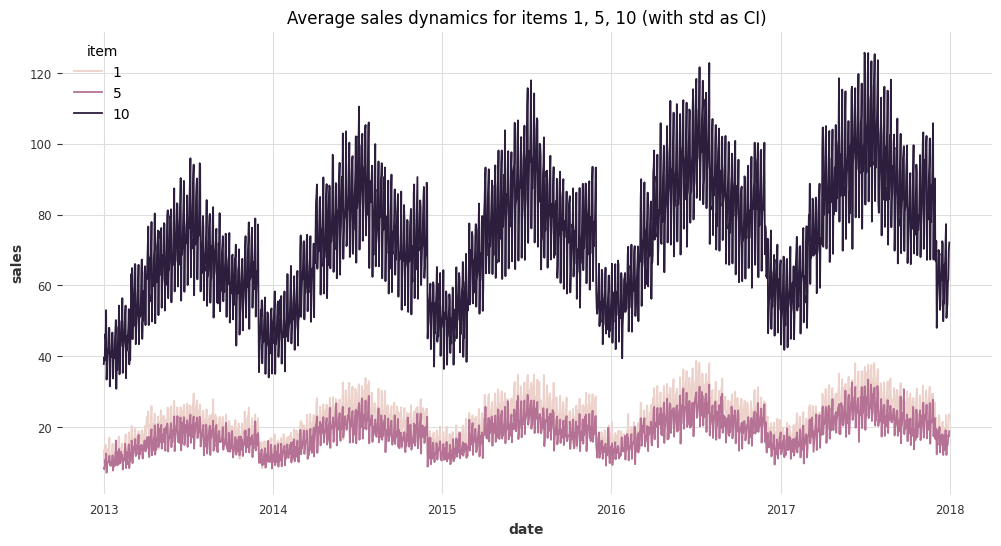

In [12]:
# 1. Average sales dynamics for several items with confidence interval
# We aggregate sales by date and item across all stores
item_sales = train_df.groupby(['date', 'item'])['sales'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=item_sales[item_sales['item'].isin([1, 5, 10])],
    x='date', y='sales', hue='item', errorbar='sd'
)
plt.title("Average sales dynamics for items 1, 5, 10 (with std as CI)")
plt.show()

/tmp/ipython-input-263128405.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=item1_sales, x='date', y='sales', hue='store', ci=None)


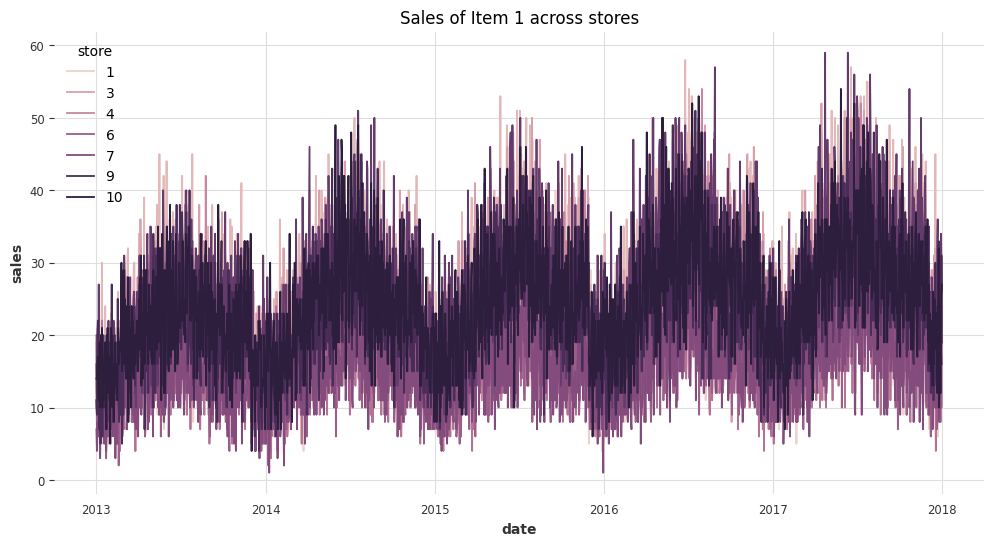

In [13]:
# 2. Sales of one item across different stores
# Here we take item=1 and compare its sales in each store
item1_sales = train_df[train_df['item'] == 1].reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=item1_sales, x='date', y='sales', hue='store', ci=None)
plt.title("Sales of Item 1 across stores")
plt.show()

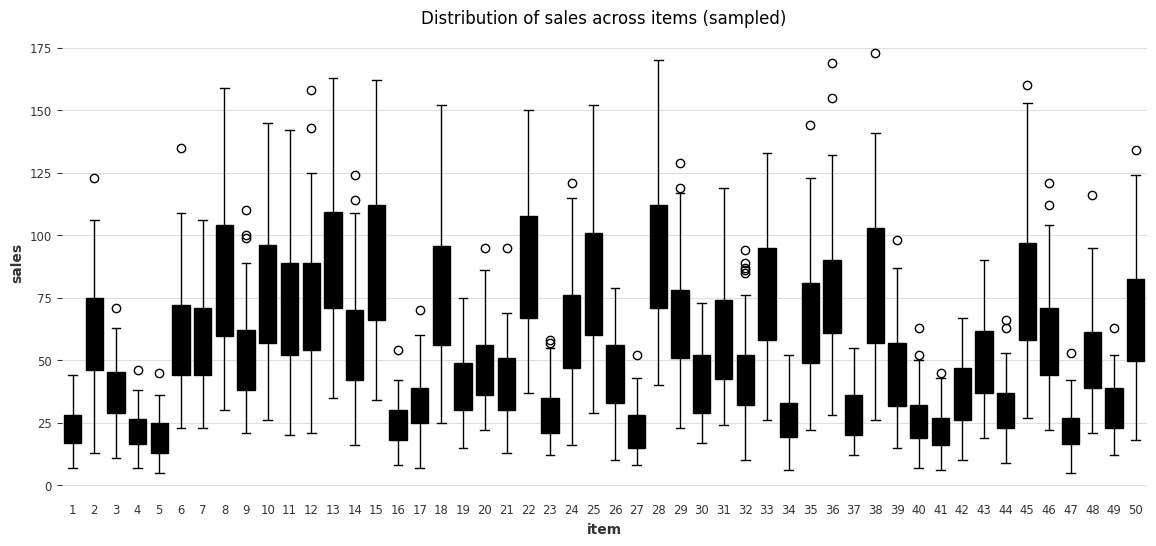

In [14]:
# 3. Distribution of sales across items
# Boxplot helps to see sales spread and outliers for different items
plt.figure(figsize=(14,6))
sns.boxplot(data=train_df.reset_index().sample(5000), x='item', y='sales')
plt.title("Distribution of sales across items (sampled)")
plt.show()

Average sales by items (chart 1):

– Strong seasonality: peaks and drops repeat every year.
– Different items have different sales levels: e.g., item 10 consistently sells more than items 1 and 5.

Sales of one item across stores (chart 2):
– The dynamics are the same in shape (trends match), but the sales level differs between stores.
– This means the “store” factor affects only the scale, not the seasonality.

Sales distribution by items (boxplot, chart 3):
– Some items show low stable demand (e.g., item 2, 4, 5).
– Some items have high variability (item 10, 23, 44) with frequent outliers.
– This variability indicates that some items are more sensitive to seasonal spikes.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

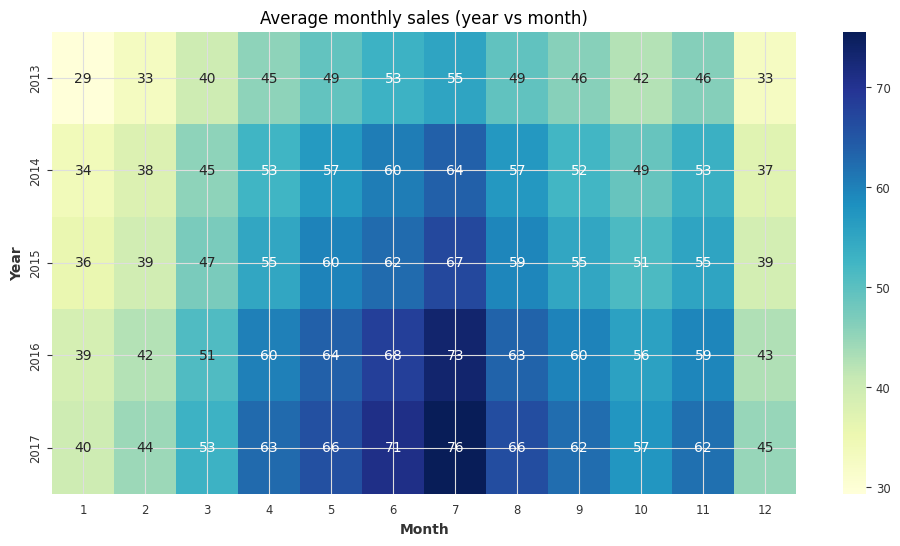

In [15]:
monthly_sales = train_df.groupby([train_df.index.year, train_df.index.month])['sales'].mean().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(monthly_sales, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Average monthly sales (year vs month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()


<Figure size 1200x400 with 0 Axes>

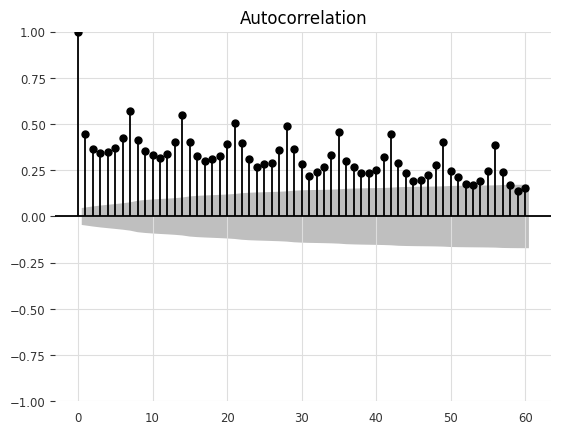

<Figure size 1200x400 with 0 Axes>

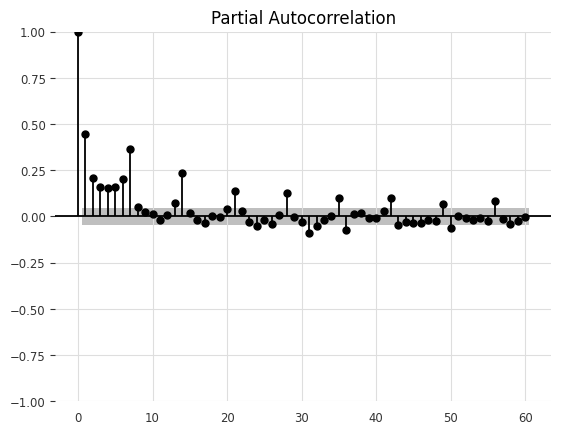

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sample_item = train_df[(train_df['store']==1) & (train_df['item']==1)]['sales']
plt.figure(figsize=(12,4))
plot_acf(sample_item, lags=60)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(sample_item, lags=60)
plt.show()


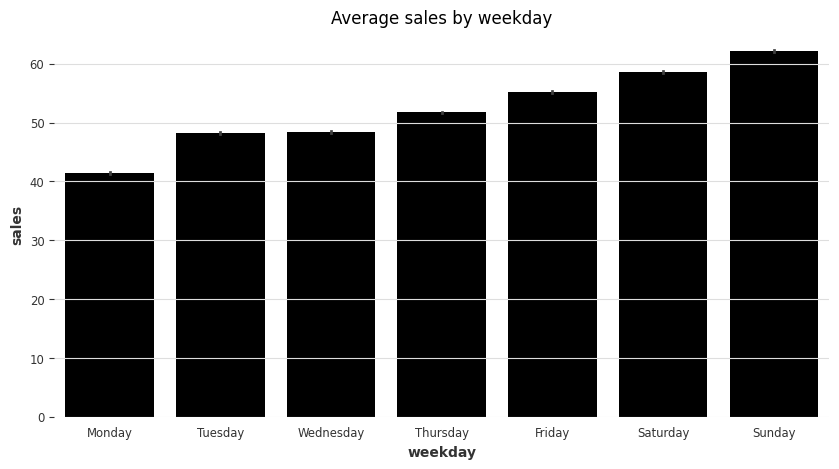

In [17]:
train_df_reset = train_df.reset_index()
train_df_reset['weekday'] = train_df_reset['date'].dt.day_name()

plt.figure(figsize=(10,5))
sns.barplot(data=train_df_reset, x='weekday', y='sales', estimator='mean', order=
            ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Average sales by weekday")
plt.show()


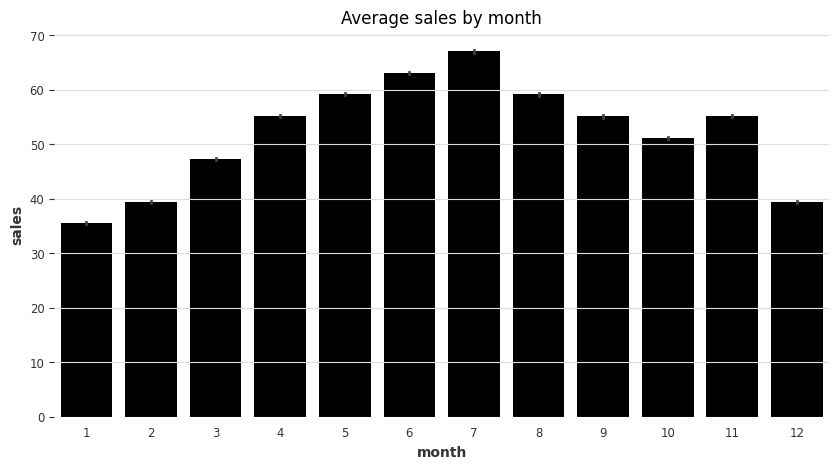

In [18]:
train_df_reset['month'] = train_df_reset['date'].dt.month

plt.figure(figsize=(10,5))
sns.barplot(data=train_df_reset, x='month', y='sales', estimator='mean')
plt.title("Average sales by month")
plt.show()


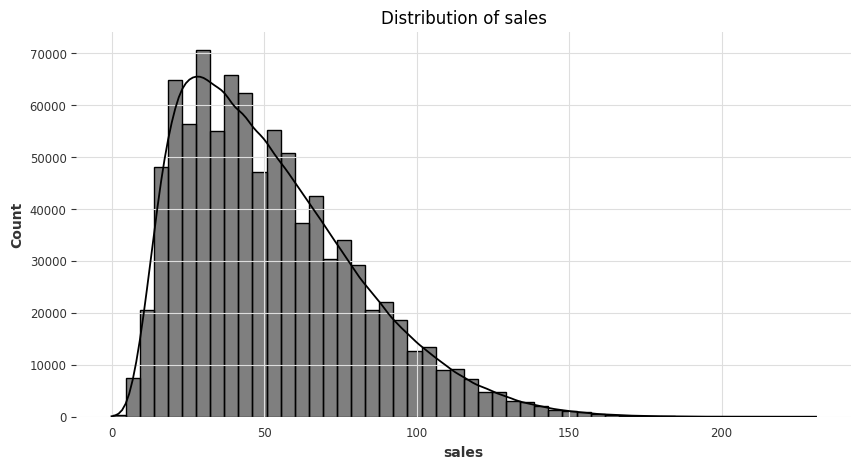

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(train_df['sales'], bins=50, kde=True)
plt.title("Distribution of sales")
plt.show()


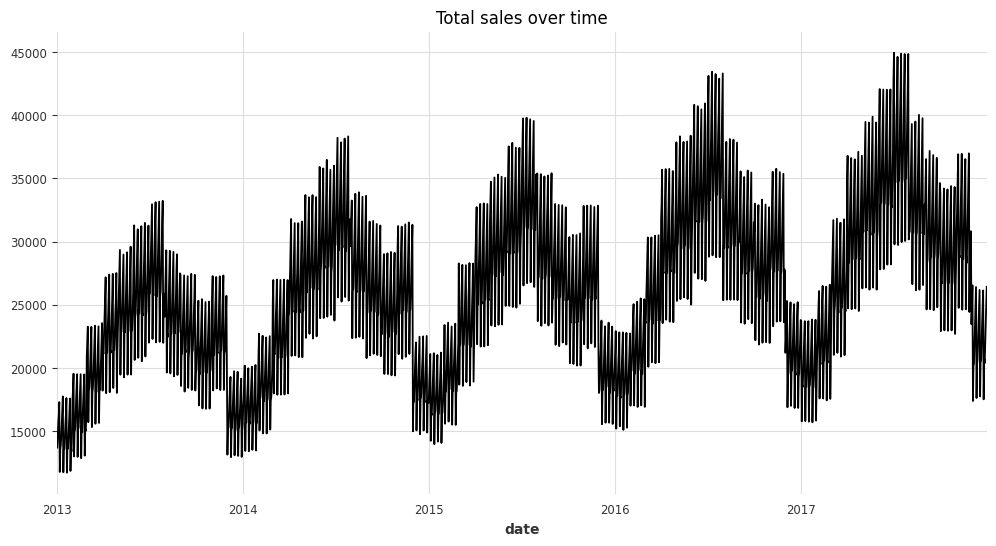

In [20]:
total_sales = train_df.groupby(train_df.index)['sales'].sum()
plt.figure(figsize=(12,6))
total_sales.plot()
plt.title("Total sales over time")
plt.show()


Additional conclusions

Yearly seasonality (heatmap):
– Sales show a clear seasonal pattern: growth starts in spring (March–April), peaks in summer (June–July), and then declines towards December.
– The average sales level increases year by year, which indicates an overall upward demand trend.

Autocorrelation (ACF/PACF):
– The ACF plot shows regular peaks at lag ~7, which confirms a weekly seasonality.
– PACF indicates that the strongest influence comes from lags 1–7, which is important for choosing ARIMA or LSTM parameters.

Days of the week (weekday plot):
– Sales increase from Monday to Sunday.
– The lowest sales are on Monday, the highest on weekends. This points to a consumer behavioral factor.

Months (month plot):
– The highest sales are observed in summer (June–July), the lowest in winter months (January–February, December).
– This once again confirms a strong seasonality in demand.

Sales distribution (histogram):
– The distribution is skewed to the right, with most values in the 0–80 range.
– This means a logarithmic transformation may be useful for modeling.

Total sales over time (trend):
– There is a stable upward trend over the 5 years.
– Fluctuations repeat every year, making the data suitable for models that account for seasonality (Prophet, SARIMA, LSTM with seasonal lags).

📌 Summary:

The data has a clear trend and seasonality (yearly, weekly, monthly).

Stores differ only in the sales scale, not in the trend.

Some items have stable demand, while others show high variability.

Suitable models should capture trend + seasonality + random fluctuations.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [21]:
store_id, item_id = 1, 1
series = make_series(train_df, store_id, item_id)

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

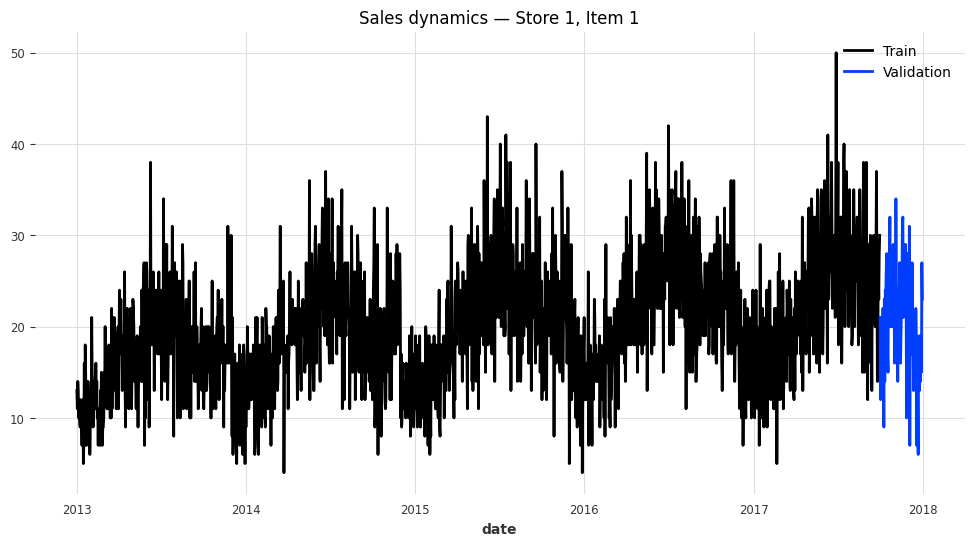

In [22]:
train_series, val_series = split_series(series, "2017-10-01")
plot_train_val(train_series, val_series, store_id, item_id)

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x400 with 0 Axes>

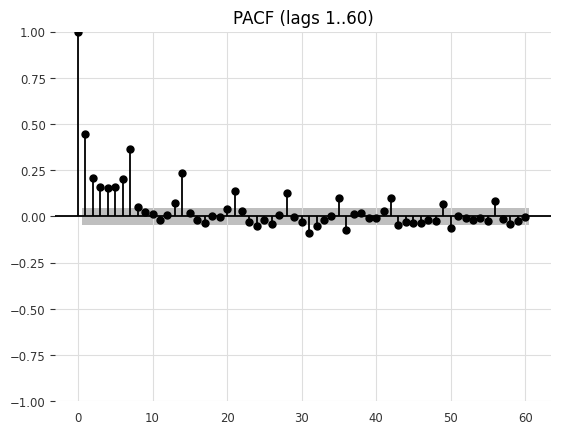

<Figure size 1000x400 with 0 Axes>

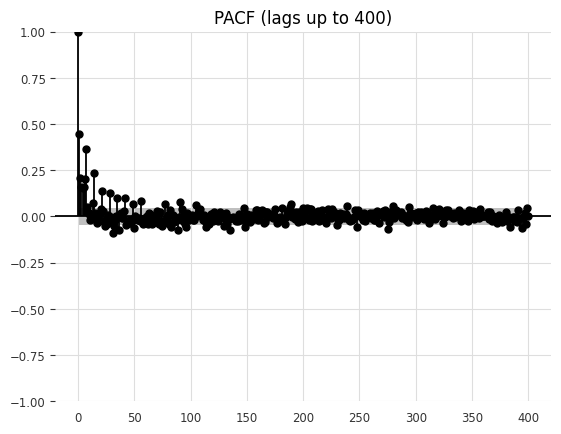

Approx. 95% critical value: 0.0459
Significant PACF lags (first 30): [  1   2   3   4   5   6   7   8  13  14  21  24  28  31  32  35  36  42
  49  50  56  75  77  83  89  91  96 105 114 130]


In [23]:
y = series.values().flatten()

# 2) PACF short horizon (до 60 лагів)

plt.figure(figsize=(10,4))
plot_pacf(y, lags=60, method="ywm")
plt.title("PACF (lags 1..60)")
plt.show()

# 3) PACF long horizon (до 400 лагів ~ рік)
plt.figure(figsize=(10,4))
plot_pacf(y, lags=400, method="ywm")
plt.title("PACF (lags up to 400)")
plt.show()

# 4) Програмний пошук значимих лагів
n = len(y)
crit = 1.96 / np.sqrt(n)

pacf_vals = sm_pacf(y, nlags=400, method="ywm")
lags = np.arange(len(pacf_vals))
mask = (lags > 0) & (np.abs(pacf_vals) > crit)
sig_lags = lags[mask]

print(f"Approx. 95% critical value: {crit:.4f}")
print("Significant PACF lags (first 30):", sig_lags[:30])

In the short horizon (1..60), we see strong lags at 1–7 and repeated peaks at 7, 14, 21, 28, confirming weekly seasonality.

Some other lags (50, 75, 100+) appear but are weaker; they may indicate longer periodicities.

Significant PACF lags list: 1, 2, 3, 4, 5, 6, 7, 8, 13, 14, 21, 24, 28, 31, 32, 35, 36, 42, 49, 50, 56, 75, 77, 83, 89, 91, 96, 105, 114, 130.

The most important for forecasting are lags 1–7 (short memory) and multiples of 7 (weekly cycle).

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [24]:
# 1) Test common periods explicitly (week, ~month, year)
for m in [7, 30, 365]:
    is_seas, period = check_seasonality(
        train_series,
        m=m,
        max_lag=m,
        alpha=0.05
    )
    print(f"Test m={m}: seasonal={is_seas}, period_returned={period}")

# 2) Auto-detect the strongest seasonality
is_seas_auto, period_auto = check_seasonality(
    train_series,
    m=None,
    max_lag=400,
    alpha=0.05
)
print(f"Auto-detected: seasonal={is_seas_auto}, best_period={period_auto}")

Test m=7: seasonal=False, period_returned=0
Test m=30: seasonal=False, period_returned=30
Test m=365: seasonal=False, period_returned=365
Auto-detected: seasonal=True, best_period=7


The data clearly shows a weekly seasonality (7 days) — confirmed by the auto-detection.

Monthly (~30) and yearly (365) seasonality were not statistically significant for this item/store.

The most relevant period to consider in modeling is 7 days.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

NaiveSeasonal MAPE: 38.17
NaiveDrift MAPE: 68.74


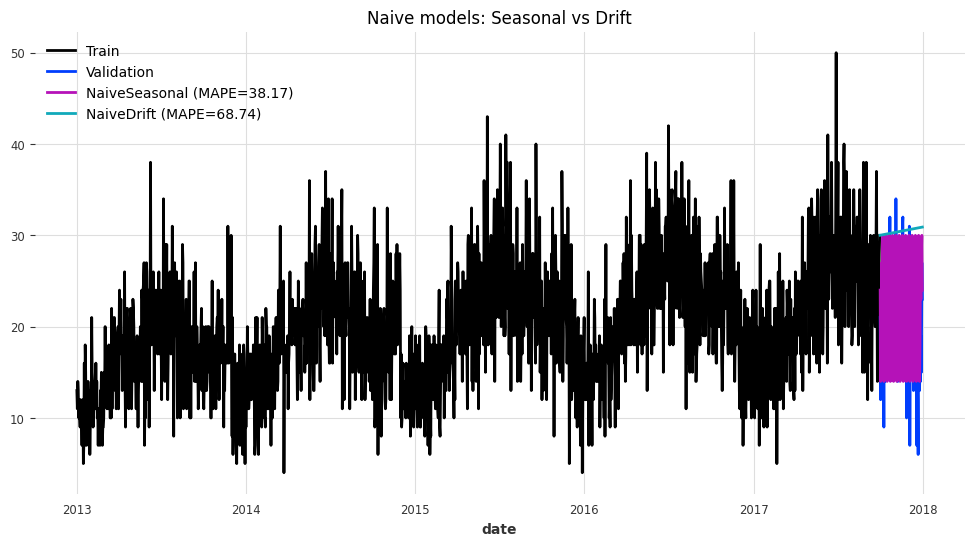

In [25]:
# =============  NaiveSeasonal model =============
naive_seasonal = NaiveSeasonal(K=7)   # English: 7-day seasonality
naive_seasonal.fit(train_series)
forecast_naive_seasonal = naive_seasonal.predict(len(val_series))

# Evaluate
mape_ns = mape(val_series, forecast_naive_seasonal)
print(f"NaiveSeasonal MAPE: {mape_ns:.2f}")

# =============  NaiveDrift model =============
naive_drift = NaiveDrift()
naive_drift.fit(train_series)
forecast_naive_drift = naive_drift.predict(len(val_series))

# Evaluate
mape_nd = mape(val_series, forecast_naive_drift)
print(f"NaiveDrift MAPE: {mape_nd:.2f}")

# =============  Visualization =============
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
forecast_naive_seasonal.plot(label=f"NaiveSeasonal (MAPE={mape_ns:.2f})")
forecast_naive_drift.plot(label=f"NaiveDrift (MAPE={mape_nd:.2f})")
plt.legend()
plt.title("Naive models: Seasonal vs Drift")
plt.show()

NaiveSeasonal (orig) MAPE: 38.17
NaiveSeasonal (log ) MAPE: 38.17
NaiveDrift    (orig, window=365) MAPE: 69.75
NaiveDrift    (log,  window=365) MAPE: 70.13
Ensemble best weight (seasonal) w=0.95 -> MAPE: 38.97


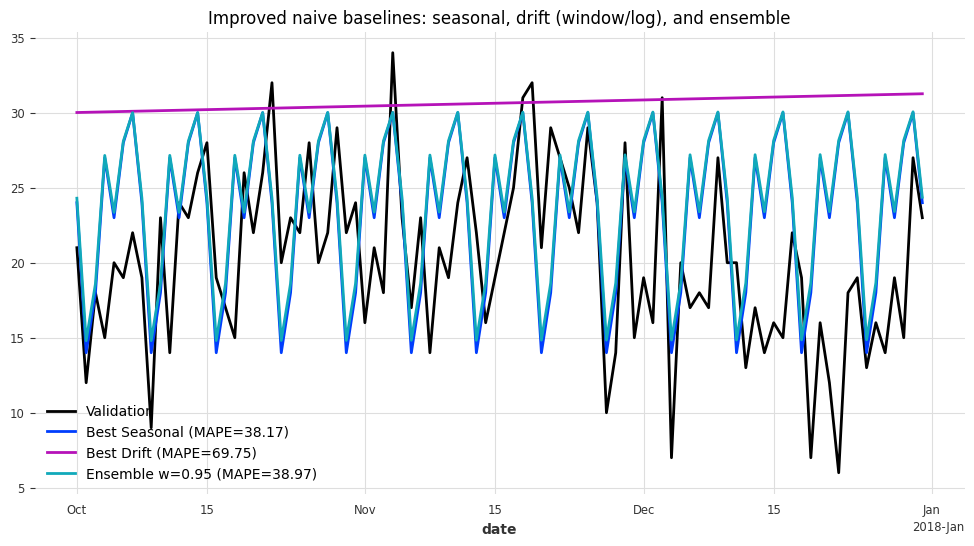

In [26]:

# ===== 0) Settings =====
H = len(val_series)          # forecast horizon (length of validation)
weekly_m = 7                 # weekly seasonality
drift_window = 365           # use only last N days to fit Drift (if available)

# ===== 1) Prepare log-transformed series (no transformers, just map) =====
train_log = train_series.map(np.log1p)
val_log   = val_series.map(np.log1p)   # optional, not used in scoring

# ===== 2) NaiveSeasonal on original scale =====
naive_seasonal_orig = NaiveSeasonal(K=weekly_m)
naive_seasonal_orig.fit(train_series)
pred_ns_orig = naive_seasonal_orig.predict(H)
mape_ns_orig = mape(val_series, pred_ns_orig)

# ===== 3) NaiveSeasonal on log scale (fit on log, then invert with expm1) =====
naive_seasonal_log = NaiveSeasonal(K=weekly_m)
naive_seasonal_log.fit(train_log)
pred_ns_log = naive_seasonal_log.predict(H)
pred_ns_log_inv = pred_ns_log.map(np.expm1)
mape_ns_log = mape(val_series, pred_ns_log_inv)

# ===== 4) NaiveDrift on original scale (fit on last drift_window days) =====
drift_train_orig = train_series[-drift_window:] if len(train_series) > drift_window else train_series
naive_drift_orig = NaiveDrift()
naive_drift_orig.fit(drift_train_orig)
pred_nd_orig = naive_drift_orig.predict(H)
mape_nd_orig = mape(val_series, pred_nd_orig)

# ===== 5) NaiveDrift on log scale (windowed) + invert =====
drift_train_log = train_log[-drift_window:] if len(train_log) > drift_window else train_log
naive_drift_log = NaiveDrift()
naive_drift_log.fit(drift_train_log)
pred_nd_log = naive_drift_log.predict(H)
pred_nd_log_inv = pred_nd_log.map(np.expm1)
mape_nd_log = mape(val_series, pred_nd_log_inv)

print(f"NaiveSeasonal (orig) MAPE: {mape_ns_orig:.2f}")
print(f"NaiveSeasonal (log ) MAPE: {mape_ns_log:.2f}")
print(f"NaiveDrift    (orig, window={drift_window}) MAPE: {mape_nd_orig:.2f}")
print(f"NaiveDrift    (log,  window={drift_window}) MAPE: {mape_nd_log:.2f}")

# ===== 6) Simple ensemble of the best seasonal + best drift with grid search for weights =====
best_seasonal_pred = pred_ns_orig if mape_ns_orig <= mape_ns_log else pred_ns_log_inv
best_drift_pred    = pred_nd_orig if mape_nd_orig <= mape_nd_log else pred_nd_log_inv

grid = np.linspace(0.50, 0.95, 10)  # weights for seasonal part
best_w, best_mape, best_ens = None, np.inf, None
for w in grid:
    ens = best_seasonal_pred * w + best_drift_pred * (1 - w)
    cur = mape(val_series, ens)
    if cur < best_mape:
        best_mape, best_w, best_ens = cur, w, ens

print(f"Ensemble best weight (seasonal) w={best_w:.2f} -> MAPE: {best_mape:.2f}")

# ===== 7) Visualization =====
plt.figure(figsize=(12,6))
val_series.plot(label="Validation")
best_seasonal_pred.plot(label=f"Best Seasonal (MAPE={min(mape_ns_orig, mape_ns_log):.2f})")
best_drift_pred.plot(label=f"Best Drift (MAPE={min(mape_nd_orig, mape_nd_log):.2f})")
best_ens.plot(label=f"Ensemble w={best_w:.2f} (MAPE={best_mape:.2f})")
plt.title("Improved naive baselines: seasonal, drift (window/log), and ensemble")
plt.legend()
plt.show()

# ===== 8) Save models and artifacts under clear names for later reuse =====
naive_seasonal_best_model = naive_seasonal_orig if mape_ns_orig <= mape_ns_log else naive_seasonal_log
naive_seasonal_best_mode  = "orig" if mape_ns_orig <= mape_ns_log else "log"

naive_drift_best_model = naive_drift_orig if mape_nd_orig <= mape_nd_log else naive_drift_log
naive_drift_best_mode  = "orig" if mape_nd_orig <= mape_nd_log else "log"

naive_best_ensemble_weight = best_w
naive_best_ensemble_pred   = best_ens          # TimeSeries forecast on validation (for reference)


9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [27]:

H = len(val_series)   # forecast horizon (validation length)

# --- 1) Fit & predict baseline (weekly seasonality) ---
naive_seasonal_baseline = NaiveSeasonal(K=7)
naive_seasonal_baseline.fit(train_series)
pred_baseline = naive_seasonal_baseline.predict(H)

# --- 2) Compute MAPE on validation ---
baseline_mape = mape(val_series, pred_baseline)
print(f"Baseline (NaiveSeasonal K=7) MAPE: {baseline_mape:.4f}")

# --- 3) Create/append to a model scoreboard ---
def init_or_append_score(df, name, mape_value):
    row = pd.DataFrame([{"model": name, "mape": float(mape_value)}])
    if df is None:
        return row
    else:
        return pd.concat([df, row], ignore_index=True)

try:
    model_scores  # if already exists, we'll append
except NameError:
    model_scores = None

model_scores = init_or_append_score(model_scores, "NaiveSeasonal(K=7)", baseline_mape)

# Sort ascending (lower MAPE is better) and show
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores

Baseline (NaiveSeasonal K=7) MAPE: 38.1749


,model,mape
0,NaiveSeasonal(K=7),38.17485


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

XGBModel MAPE: 27.9479


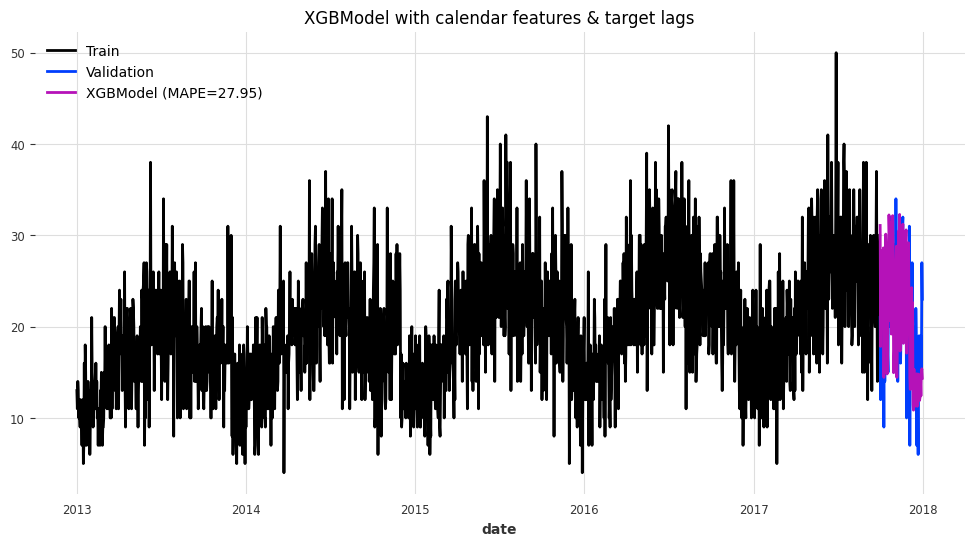

,model,mape
0,XGBModel(lags<0 + calendar),27.947926
1,NaiveSeasonal(K=7),38.174850


In [28]:
# Helper: robust single-component rename across older Darts APIs
def rename_single_component(ts: TimeSeries, new_name: str) -> TimeSeries:
    try:  # old API signature: with_columns_renamed(old_names, new_names)
        old = [ts.components[0]]
        return ts.with_columns_renamed(old, [new_name])
    except Exception:
        # fallback: rebuild series with the desired column name
        vals = ts.values(copy=False).squeeze()
        return TimeSeries.from_times_and_values(ts.time_index, vals, columns=[new_name])

# 1) Build calendar future covariates on the whole timeline (train + val)
#    NOTE: in this Darts version call datetime_attribute_timeseries ONCE per attribute.
time_index = series.time_index

dow_1h   = datetime_attribute_timeseries(time_index=time_index,
                                         attribute="day_of_week", one_hot=True)
month_1h = datetime_attribute_timeseries(time_index=time_index,
                                         attribute="month", one_hot=True)

# binary is_weekend from raw day_of_week (>=5)
dow_raw = datetime_attribute_timeseries(time_index=time_index,
                                        attribute="day_of_week", one_hot=False)
is_weekend = dow_raw.map(lambda v: (v >= 5).astype(float))
is_weekend = rename_single_component(is_weekend, "is_weekend")

# stack all calendar features together
future_cov = dow_1h.stack(month_1h).stack(is_weekend)

# 2) (Optional but helpful) scale target and covariates
scaler_y = Scaler()
scaler_c = Scaler()

train_y = scaler_y.fit_transform(train_series)
val_y   = scaler_y.transform(val_series)

future_cov_scaled = scaler_c.fit_transform(future_cov)
future_cov_train  = future_cov_scaled.slice_intersect(train_series)   # align to train
future_cov_all    = future_cov_scaled                                # full (train+val) for predict

# 3) Define XGBModel
#    IMPORTANT: in older Darts, target `lags` must be strictly NEGATIVE (past lags).
#    We capture weekly seasonality and short memory with multiples of 7.
xgb = XGBModel(
    lags=[-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-49,-56],  # past target lags
    lags_future_covariates=[0],                                # use contemporaneous calendar features
    output_chunk_length=1,
    random_state=42,
)

# 4) Fit on TRAIN (scaled)
xgb.fit(series=train_y, future_covariates=future_cov_train, verbose=False)

# 5) Predict on VALID horizon (needs covariates that span the forecast horizon)
H = len(val_series)
pred_scaled = xgb.predict(n=H, series=train_y, future_covariates=future_cov_all)

# invert scaling back
pred = scaler_y.inverse_transform(pred_scaled)

# 6) Evaluate & visualize
xgb_mape = mape(val_series, pred)
print(f"XGBModel MAPE: {xgb_mape:.4f}")

plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
pred.plot(label=f"XGBModel (MAPE={xgb_mape:.2f})")
plt.title("XGBModel with calendar features & target lags")
plt.legend(); plt.show()

# 7) Add to scoreboard
try:
    model_scores
except NameError:
    model_scores = None

row = pd.DataFrame([{"model": "XGBModel(lags<0 + calendar)", "mape": float(xgb_mape)}])
model_scores = row if model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores

XGBModel v2 (lags + calendar + rolling) MAPE: 24.8472


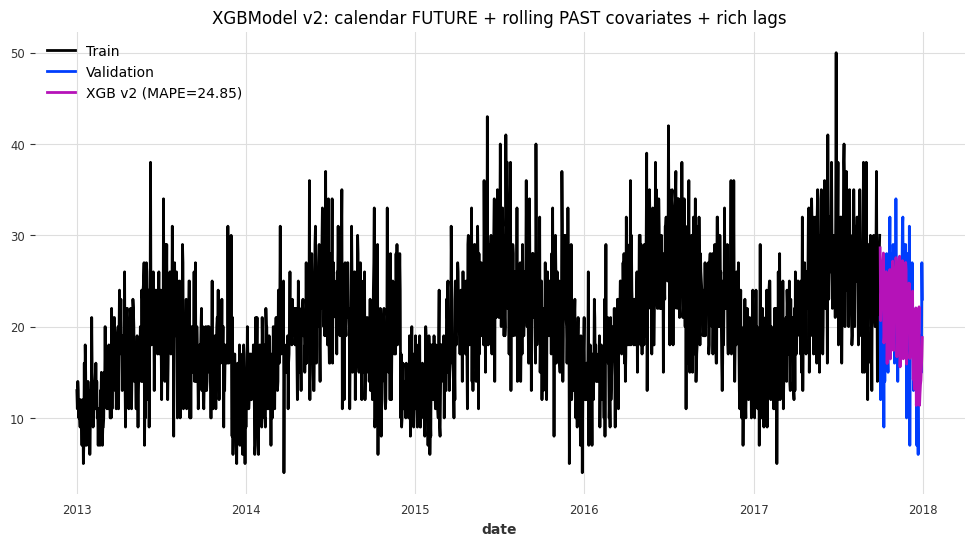

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel(lags<0 + calendar),27.947926
2,NaiveSeasonal(K=7),38.174850


In [29]:
# ---------- helpers ----------
def rename_single_component(ts: TimeSeries, new_name: str) -> TimeSeries:
    """Robust single-component rename across older Darts APIs."""
    try:
        old = [ts.components[0]]
        return ts.with_columns_renamed(old, [new_name])
    except Exception:
        vals = ts.values(copy=False).squeeze()
        return TimeSeries.from_times_and_values(ts.time_index, vals, columns=[new_name])

def make_calendar_cov(ts: TimeSeries) -> TimeSeries:
    """One-hot day_of_week + month + binary is_weekend as FUTURE covariates."""
    idx = ts.time_index
    dow_1h   = datetime_attribute_timeseries(time_index=idx, attribute="day_of_week", one_hot=True)
    month_1h = datetime_attribute_timeseries(time_index=idx, attribute="month",       one_hot=True)
    dow_raw  = datetime_attribute_timeseries(time_index=idx, attribute="day_of_week", one_hot=False)
    is_weekend = rename_single_component(dow_raw.map(lambda v: (v >= 5).astype(float)), "is_weekend")
    return dow_1h.stack(month_1h).stack(is_weekend)

def make_rolling_past_cov(ts: TimeSeries,
                          windows_mean=(7,14,28),
                          windows_std=(7,14,28),
                          windows_median=(7,14)) -> TimeSeries:
    """
    Rolling aggregates of the TARGET as PAST covariates.
    Works on older Darts: uses time_index + values().
    """
    idx = ts.time_index
    y   = ts.values(copy=False).squeeze()               # numpy array shape [T]
    df  = pd.DataFrame({"y": y}, index=idx)

    for w in windows_mean:
        df[f"roll_mean_{w}"] = df["y"].rolling(w, min_periods=1).mean()
    for w in windows_std:
        df[f"roll_std_{w}"]  = df["y"].rolling(w, min_periods=2).std().fillna(0.0)
    for w in windows_median:
        df[f"roll_med_{w}"]  = df["y"].rolling(w, min_periods=1).median()

    cols = [c for c in df.columns if c != "y"]
    return TimeSeries.from_times_and_values(df.index, df[cols].values, columns=cols)

# ---------- 1) covariates ----------
future_cov_all = make_calendar_cov(series)        # future covariates (calendar)
past_cov_all   = make_rolling_past_cov(series)    # past covariates (rolling stats)

# ---------- 2) scaling ----------
scaler_y  = Scaler()
scaler_fc = Scaler()
scaler_pc = Scaler()

train_y = scaler_y.fit_transform(train_series)
val_y   = scaler_y.transform(val_series)

future_cov_scaled = scaler_fc.fit_transform(future_cov_all)
past_cov_scaled   = scaler_pc.fit_transform(past_cov_all)

future_cov_train = future_cov_scaled.slice_intersect(train_series)
past_cov_train   = past_cov_scaled.slice_intersect(train_series)

# ---------- 3) model (STRICTLY negative target lags for older Darts) ----------
xgb_v2 = XGBModel(
    lags=[-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-49,-56,-63,-70,-77,-84,-91],
    lags_future_covariates=[0],                 # contemporaneous calendar features
    lags_past_covariates=[-1,-7,-14,-28],       # use recent rolling features
    output_chunk_length=1,
    # light tuning
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)

# ---------- 4) fit & predict ----------
xgb_v2.fit(series=train_y,
           past_covariates=past_cov_train,
           future_covariates=future_cov_train,
           verbose=False)

H = len(val_series)
pred_scaled_v2 = xgb_v2.predict(
    n=H,
    series=train_y,
    past_covariates=past_cov_scaled,
    future_covariates=future_cov_scaled
)
pred_v2 = scaler_y.inverse_transform(pred_scaled_v2)

# ---------- 5) evaluate + plot ----------
mape_v2 = mape(val_series, pred_v2)
print(f"XGBModel v2 (lags + calendar + rolling) MAPE: {mape_v2:.4f}")

plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
pred_v2.plot(label=f"XGB v2 (MAPE={mape_v2:.2f})")
plt.title("XGBModel v2: calendar FUTURE + rolling PAST covariates + rich lags")
plt.legend(); plt.show()

# ---------- 6) add to scoreboard ----------
try:
    model_scores
except NameError:
    model_scores = None
row = pd.DataFrame([{"model": "XGBModel_v2(cal+rolling)", "mape": float(mape_v2)}])
model_scores = row if model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores

XGBModel v3 (enhanced past covs) MAPE: 25.1853


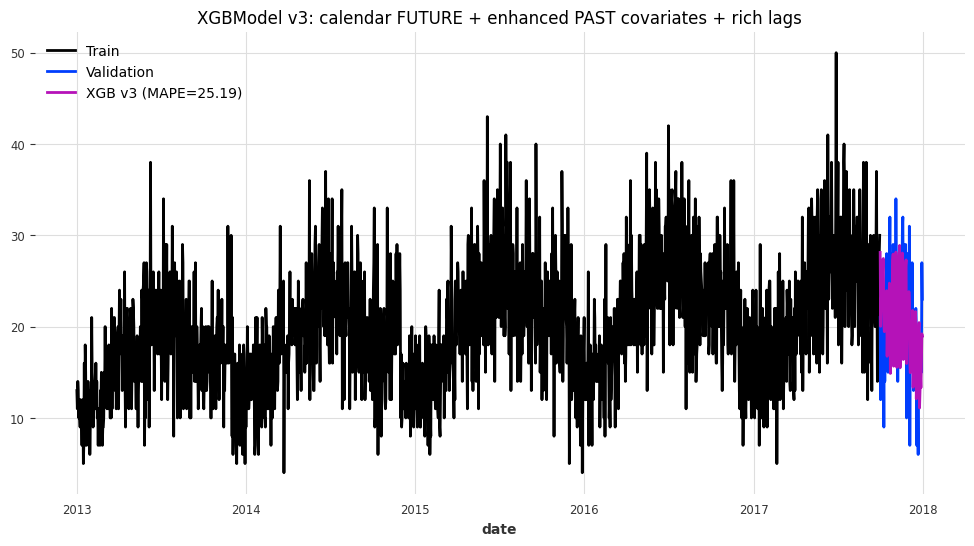

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v3(cal+enhanced rolling),25.185289
2,XGBModel(lags<0 + calendar),27.947926
3,NaiveSeasonal(K=7),38.174850


In [30]:
def make_enhanced_past_cov(ts: TimeSeries) -> TimeSeries:
    """
    Build richer past covariates from target:
      - rolling mean/std/median (7/14/28)
      - EWMA (spans 7/14/28)
      - rolling min/max (7/28)
    Works on older Darts using time_index + values().
    """
    idx = ts.time_index
    y   = ts.values(copy=False).squeeze()
    df  = pd.DataFrame({"y": y}, index=idx)

    # Rolling stats
    for w in (7, 14, 28):
        df[f"roll_mean_{w}"] = df["y"].rolling(w, min_periods=1).mean()
        df[f"roll_std_{w}"]  = df["y"].rolling(w, min_periods=2).std().fillna(0.0)
        df[f"roll_med_{w}"]  = df["y"].rolling(w, min_periods=1).median()

    # EWMA (exponentially weighted means)
    for span in (7, 14, 28):
        df[f"ewma_{span}"] = df["y"].ewm(span=span, adjust=False).mean()

    # Rolling min/max
    for w in (7, 28):
        df[f"roll_min_{w}"] = df["y"].rolling(w, min_periods=1).min()
        df[f"roll_max_{w}"] = df["y"].rolling(w, min_periods=1).max()

    cols = [c for c in df.columns if c != "y"]
    return TimeSeries.from_times_and_values(df.index, df[cols].values, columns=cols)

# --- 1) covariates ---
future_cov_all = make_calendar_cov(series)
past_cov_all   = make_enhanced_past_cov(series)

# --- 2) scaling ---
scaler_y  = Scaler()
scaler_fc = Scaler()
scaler_pc = Scaler()

train_y = scaler_y.fit_transform(train_series)
val_y   = scaler_y.transform(val_series)

future_cov_scaled = scaler_fc.fit_transform(future_cov_all)
past_cov_scaled   = scaler_pc.fit_transform(past_cov_all)

future_cov_train = future_cov_scaled.slice_intersect(train_series)
past_cov_train   = past_cov_scaled.slice_intersect(train_series)

# --- 3) model (strictly negative target lags!) ---
xgb_v3 = XGBModel(
    lags=[-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-49,-56,-63,-70,-77,-84,-91],
    lags_future_covariates=[0],
    lags_past_covariates=[-1,-7,-14,-28,-56],  # use recent windows from enhanced past covs
    output_chunk_length=1,
    n_estimators=900,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)

# --- 4) fit & predict ---
xgb_v3.fit(series=train_y,
           past_covariates=past_cov_train,
           future_covariates=future_cov_train,
           verbose=False)

H = len(val_series)
pred_scaled_v3 = xgb_v3.predict(
    n=H,
    series=train_y,
    past_covariates=past_cov_scaled,
    future_covariates=future_cov_scaled
)
pred_v3 = scaler_y.inverse_transform(pred_scaled_v3)

# --- 5) evaluate & plot ---
mape_v3 = mape(val_series, pred_v3)
print(f"XGBModel v3 (enhanced past covs) MAPE: {mape_v3:.4f}")

plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
pred_v3.plot(label=f"XGB v3 (MAPE={mape_v3:.2f})")
plt.title("XGBModel v3: calendar FUTURE + enhanced PAST covariates + rich lags")
plt.legend(); plt.show()

# --- 6) scoreboard ---
row = pd.DataFrame([{"model": "XGBModel_v3(cal+enhanced rolling)", "mape": float(mape_v3)}])
model_scores = row if 'model_scores' not in globals() or model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores

In [31]:

# === Small param search with rolling backtesting (3 folds) ===
from datetime import timedelta

def fit_eval_xgb(params):
    """Train XGB with given params and return backtesting MAPE (avg over folds)."""
    # build model
    model = XGBModel(
        lags=[-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-49,-56,-63,-70,-77,-84,-91],
        lags_future_covariates=[0],
        lags_past_covariates=[-1,-7,-14,-28,-56],
        output_chunk_length=1,
        random_state=42,
        **params
    )

    # 3 rolling folds starting in 2017: train up to t, predict next 30 days
    cut_points = ["2017-06-01", "2017-08-01", "2017-10-01"]
    horizons   = [30, 30, len(val_series)]  # last fold uses your real val horizon

    fold_mapes = []
    for cp, h in zip(cut_points, horizons):
        cp = pd.Timestamp(cp)
        tr  = series.drop_after(cp - timedelta(days=1))
        vl  = series.slice(cp, cp + timedelta(days=h-1))

        # scale and slice covariates for this fold
        sy = Scaler(); sfc = Scaler(); spc = Scaler()
        tr_y = sy.fit_transform(tr)
        vl_y = sy.transform(vl)

        fc_all = make_calendar_cov(series)
        pc_all = make_enhanced_past_cov(series)
        fc_sc  = sfc.fit_transform(fc_all)
        pc_sc  = spc.fit_transform(pc_all)

        fc_tr = fc_sc.slice_intersect(tr)
        pc_tr = pc_sc.slice_intersect(tr)

        model.fit(series=tr_y, future_covariates=fc_tr, past_covariates=pc_tr, verbose=False)
        pred = model.predict(n=h, series=tr_y, future_covariates=fc_sc, past_covariates=pc_sc)
        pred = sy.inverse_transform(pred)

        fold_mapes.append(mape(vl, pred))

    return np.mean(fold_mapes)

param_grid = [
    {"n_estimators": 700, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators":1000, "max_depth": 7, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators":1200, "max_depth": 8, "learning_rate": 0.04, "subsample": 0.85,"colsample_bytree": 0.85},
]

scores = []
for p in param_grid:
    score = fit_eval_xgb(p)
    print(f"params={p} -> backtest MAPE={score:.3f}")
    scores.append((score, p))

best_score, best_params = min(scores, key=lambda x: x[0])
print("\nBest params:", best_params, "avg backtest MAPE:", round(best_score,3))


params={'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9} -> backtest MAPE=19.455


params={'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9} -> backtest MAPE=19.766


params={'n_estimators': 1200, 'max_depth': 8, 'learning_rate': 0.04, 'subsample': 0.85, 'colsample_bytree': 0.85} -> backtest MAPE=19.578

Best params: {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9} avg backtest MAPE: 19.455


Tuned XGB (backtest best) MAPE on validation: 24.8472


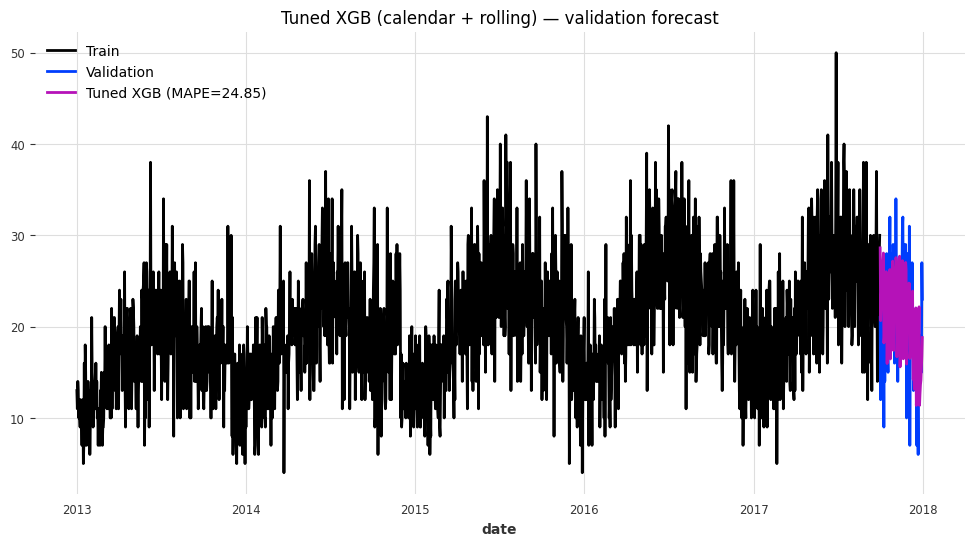

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v2_tuned(backtest best),24.847229
2,XGBModel_v3(cal+enhanced rolling),25.185289
3,XGBModel(lags<0 + calendar),27.947926
4,NaiveSeasonal(K=7),38.174850


In [32]:
# 1) Best params found by backtesting
best_params = {
    "n_estimators": 700,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}

# 2) Build covariates exactly like in v2 (calendar FUTURE + rolling PAST)
future_cov_all = make_calendar_cov(series)
past_cov_all   = make_rolling_past_cov(series)

# 3) Scale target + covariates
sy  = Scaler(); sfc = Scaler(); spc = Scaler()
train_y = sy.fit_transform(train_series)
val_y   = sy.transform(val_series)

fc_sc_all = sfc.fit_transform(future_cov_all)
pc_sc_all = spc.fit_transform(past_cov_all)

fc_tr = fc_sc_all.slice_intersect(train_series)
pc_tr = pc_sc_all.slice_intersect(train_series)

# 4) Fit tuned model (STRICTLY negative target lags for older Darts)
best_xgb = XGBModel(
    lags=[-1,-2,-3,-4,-5,-6,-7,-14,-21,-28,-35,-42,-49,-56,-63,-70,-77,-84,-91],
    lags_future_covariates=[0],
    lags_past_covariates=[-1,-7,-14,-28],   # v2 setting that worked best
    output_chunk_length=1,
    random_state=42,
    **best_params
)
best_xgb.fit(series=train_y, future_covariates=fc_tr, past_covariates=pc_tr, verbose=False)

# 5) Predict on validation horizon and invert scaling
H = len(val_series)
pred_sc = best_xgb.predict(n=H, series=train_y,
                           future_covariates=fc_sc_all,
                           past_covariates=pc_sc_all)
pred = sy.inverse_transform(pred_sc)

# 6) Score, plot, and register
best_mape = float(mape(val_series, pred))
print(f"Tuned XGB (backtest best) MAPE on validation: {best_mape:.4f}")

plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
pred.plot(label=f"Tuned XGB (MAPE={best_mape:.2f})")
plt.title("Tuned XGB (calendar + rolling) — validation forecast")
plt.legend(); plt.show()

# Update scoreboard
row = pd.DataFrame([{"model": "XGBModel_v2_tuned(backtest best)", "mape": best_mape}])
try:
    model_scores
except NameError:
    model_scores = None
model_scores = row if model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores


**Висновок**

XGBModel з календарними та ролінговими ознаками — поточний найкращий бейзлайн для нашого ряду (≈24.85 MAPE), який значно випереджає наївну сезонну модель (~38.17). Модель стабільна, інтерпретована через внесок ознак і готова для подальшого узагальнення на всі 50×10 серій та для сабмішена.

Якщо потрібно ще поліпшити:

перевірити LightGBM/CatBoost і прості ансамблі з XGB;

додати свята/чорну п’ятницю (бінарні прапорці) як future-covariates;

використати багаторядний підхід (global model) і/або cross-validation для стійкішої оцінки.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

ES add trend + mul season (sp=7), damped: MAPE=35.9161
ES add trend + add season (sp=7), damped: MAPE=36.6453
ES LOG + mul season (sp=7), damped: MAPE=35.0546
ES LOG + add season (sp=7), damped: MAPE=35.1890

Best ES config: ES LOG + mul season (sp=7), damped -> MAPE=35.0546


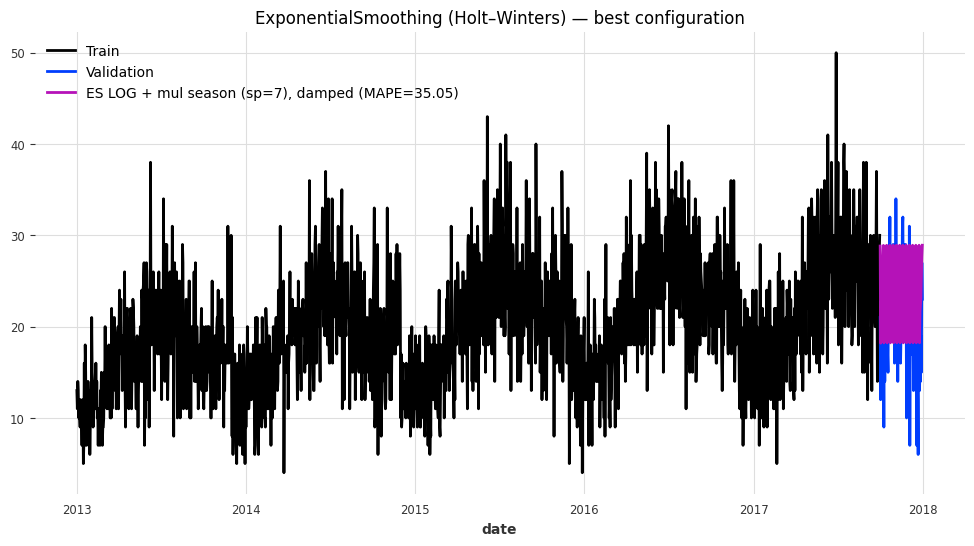

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v2_tuned(backtest best),24.847229
2,XGBModel_v3(cal+enhanced rolling),25.185289
3,XGBModel(lags<0 + calendar),27.947926
4,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
5,NaiveSeasonal(K=7),38.174850


In [33]:
# ExponentialSmoothing (Holt–Winters): robust mapping for trend/seasonal (enums or fallback with .value)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace

from darts.models import ExponentialSmoothing
from darts.metrics import mape

# ---- try to import enums; if not available, we'll create simple objects with .value ----
try:
    from darts.models.forecasting.exponential_smoothing import Trend, Seasonality
    HAS_ENUMS = True
except Exception:
    Trend = Seasonality = None
    HAS_ENUMS = False

def _make_trend(val):      # val in {"add", "mul", None}
    if val is None:
        return None
    if HAS_ENUMS:
        return Trend.ADDITIVE if val == "add" else Trend.MULTIPLICATIVE
    # fallback: any object with attribute `.value` is OK for darts
    return SimpleNamespace(value=("add" if val == "add" else "mul"))

def _make_seasonal(val):   # val in {"add", "mul", None}
    if val is None:
        return None
    if HAS_ENUMS:
        return Seasonality.ADDITIVE if val == "add" else Seasonality.MULTIPLICATIVE
    return SimpleNamespace(value=("add" if val == "add" else "mul"))

def es_fit_eval(name, trend, seasonal, sp, damped, use_log=False):
    """
    Fit ExponentialSmoothing on train_series and evaluate on val_series.
    `trend`/`seasonal` are 'add'/'mul'/None; internally mapped to enums or SimpleNamespace(value=...).
    """
    y_tr = train_series if not use_log else train_series.map(np.log1p)

    model = ExponentialSmoothing(
        trend=_make_trend(trend),
        seasonal=_make_seasonal(seasonal),
        seasonal_periods=sp,
        damped=damped,
    )
    model.fit(y_tr)

    H = len(val_series)
    fc = model.predict(H)
    fc_out = fc if not use_log else fc.map(np.expm1)

    score = float(mape(val_series, fc_out))
    print(f"{name}: MAPE={score:.4f}")
    return score, fc_out, model, name

# ---- configs to try (weekly seasonality sp=7) ----
configs = [
    ("ES add trend + mul season (sp=7), damped", "add", "mul", 7, True,  False),
    ("ES add trend + add season (sp=7), damped", "add", "add", 7, True,  False),
    ("ES LOG + mul season (sp=7), damped",       "add", "mul", 7, True,  True ),
    ("ES LOG + add season (sp=7), damped",       "add", "add", 7, True,  True ),
]

results = []
for name, tr, seas, sp, dp, lg in configs:
    results.append(es_fit_eval(name, tr, seas, sp, dp, use_log=lg))

# ---- best ES ----
best_mape, best_pred, best_model, best_name = sorted(results, key=lambda x: x[0])[0]
print(f"\nBest ES config: {best_name} -> MAPE={best_mape:.4f}")

plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
best_pred.plot(label=f"{best_name} (MAPE={best_mape:.2f})")
plt.title("ExponentialSmoothing (Holt–Winters) — best configuration")
plt.legend(); plt.show()

# ---- add to scoreboard ----
row = pd.DataFrame([{"model": f"ExpSmooth | {best_name}", "mape": best_mape}])
try:
    model_scores
except NameError:
    model_scores = None
model_scores = row if model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores


ExponentialSmoothing (Holt–Winters) показав суттєво гіршу якість (≈35 MAPE) порівняно з XGB (~24.85 MAPE). Це очікувано, адже ES моделює лише одну сезонність і лінійні компоненти, тоді як у даних є сильна тижнева та повільна річна сезонності, змінна амплітуда та викиди.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

ARIMA(0, 0, 1): order=(0, 0, 1), MAPE=99.8114
ARIMA(0, 0, 2): order=(0, 0, 2), MAPE=99.3822
ARIMA(1, 0, 0): order=(1, 0, 0), MAPE=47.1541


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1, 0, 1): order=(1, 0, 1), MAPE=40.8492
ARIMA(1, 0, 2): order=(1, 0, 2), MAPE=41.0207
ARIMA(2, 0, 0): order=(2, 0, 0), MAPE=29.6234
ARIMA(2, 0, 1): order=(2, 0, 1), MAPE=40.9427
ARIMA(2, 0, 2): order=(2, 0, 2), MAPE=40.8002
ARIMA(0, 1, 0): order=(0, 1, 0), MAPE=66.2273
ARIMA(0, 1, 1): order=(0, 1, 1), MAPE=38.7126
ARIMA(0, 1, 2): order=(0, 1, 2), MAPE=38.7835
ARIMA(1, 1, 0): order=(1, 1, 0), MAPE=62.9972
ARIMA(1, 1, 1): order=(1, 1, 1), MAPE=38.7906
ARIMA(1, 1, 2): order=(1, 1, 2), MAPE=38.6854
ARIMA(2, 1, 0): order=(2, 1, 0), MAPE=57.0198
ARIMA(2, 1, 1): order=(2, 1, 1), MAPE=38.6017
ARIMA(2, 1, 2): order=(2, 1, 2), MAPE=38.7276

Best ARIMA: ARIMA(2, 0, 0)  MAPE=29.6234


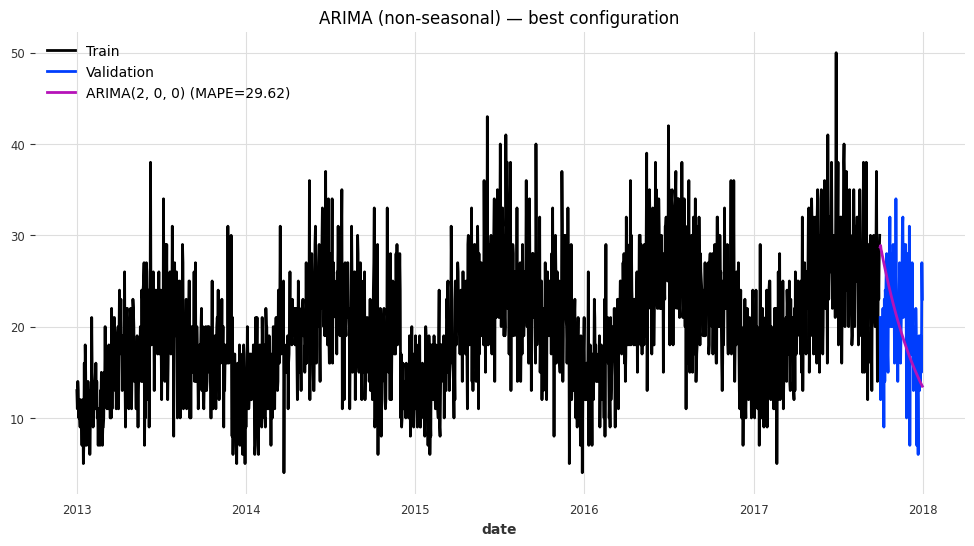

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v2_tuned(backtest best),24.847229
2,XGBModel_v3(cal+enhanced rolling),25.185289
3,XGBModel(lags<0 + calendar),27.947926
4,"ARIMA | ARIMA(2, 0, 0)",29.623366
5,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
6,NaiveSeasonal(K=7),38.174850


In [34]:
# === Plain ARIMA (non-seasonal) via statsmodels ===
# EN: Small grid over (p,d,q). We evaluate on validation by MAPE, pick the best and plot.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from darts import TimeSeries
from darts.metrics import mape

def arima_fit_eval(name, order, use_log=True):
    """
    EN: Fit ARIMA(p,d,q) on train_series (optionally in log-space), forecast len(val) steps,
        wrap back to Darts TimeSeries and compute MAPE.
    RU: Обучает ARIMA(p,d,q) на train_series (при желании в лог-пространстве),
        прогнозирует длину валидации, возвращает Darts TimeSeries и MAPE.
    """
    # 1) get numpy endog
    y_tr = train_series.values().flatten()
    if use_log:
        y_tr = np.log1p(y_tr)

    # 2) fit ARIMA (no seasonality)
    model = ARIMA(
        endog=y_tr,
        order=order,
        trend='n',  # no deterministic trend when differencing is used
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit()

    # 3) forecast H steps
    H = len(val_series)
    fc = res.forecast(steps=H)
    if use_log:
        fc = np.expm1(fc)

    # 4) wrap to Darts TS on validation index and score
    pred_ts = TimeSeries.from_times_and_values(val_series.time_index, np.asarray(fc))
    score = float(mape(val_series, pred_ts))
    print(f"{name}: order={order}, MAPE={score:.4f}")
    return score, pred_ts, res, name

# --- compact grid of p,d,q ---
orders = []
for d in [0, 1]:
    for p in [0, 1, 2]:
        for q in [0, 1, 2]:
            if not (p == 0 and d == 0 and q == 0):
                orders.append((p, d, q))

results = []
for od in orders:
    try:
        results.append(arima_fit_eval(f"ARIMA{od}", order=od, use_log=True))
    except Exception as e:
        print("skip", od, "->", e)

if len(results) == 0:
    raise RuntimeError("No ARIMA configuration fitted successfully. Try expanding the grid.")

# pick best by MAPE
best_mape, best_pred, best_res, best_name = sorted(results, key=lambda x: x[0])[0]
print(f"\nBest ARIMA: {best_name}  MAPE={best_mape:.4f}")

# plot
plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
best_pred.plot(label=f"{best_name} (MAPE={best_mape:.2f})")
plt.title("ARIMA (non-seasonal) — best configuration")
plt.legend(); plt.show()

# add to the shared scoreboard
row = pd.DataFrame([{"model": f"ARIMA | {best_name}", "mape": best_mape}])
try:
    model_scores
except NameError:
    model_scores = None
model_scores = row if model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(1, 1, 1)x(1, 0, 1, 7): order=(1, 1, 1), seas=(1, 0, 1, 7), MAPE=37.7122
SARIMA(1, 1, 1)x(0, 1, 1, 7): order=(1, 1, 1), seas=(0, 1, 1, 7), MAPE=37.7527
SARIMA(1, 1, 1)x(1, 1, 1, 7): order=(1, 1, 1), seas=(1, 1, 1, 7), MAPE=37.9565
SARIMA(1, 1, 1)x(0, 1, 0, 7): order=(1, 1, 1), seas=(0, 1, 0, 7), MAPE=39.8453
SARIMA(2, 1, 1)x(1, 0, 1, 7): order=(2, 1, 1), seas=(1, 0, 1, 7), MAPE=37.7121
SARIMA(2, 1, 1)x(0, 1, 1, 7): order=(2, 1, 1), seas=(0, 1, 1, 7), MAPE=37.7596
SARIMA(2, 1, 1)x(1, 1, 1, 7): order=(2, 1, 1), seas=(1, 1, 1, 7), MAPE=37.9439
SARIMA(2, 1, 1)x(0, 1, 0, 7): order=(2, 1, 1), seas=(0, 1, 0, 7), MAPE=39.8346
SARIMA(1, 1, 2)x(1, 0, 1, 7): order=(1, 1, 2), seas=(1, 0, 1, 7), MAPE=37.6840
SARIMA(1, 1, 2)x(0, 1, 1, 7): order=(1, 1, 2), seas=(0, 1, 1, 7), MAPE=37.9655
SARIMA(1, 1, 2)x(1, 1, 1, 7): order=(1, 1, 2), seas=(1, 1, 1, 7), MAPE=37.9489
SARIMA(1, 1, 2)x(0, 1, 0, 7): order=(1, 1, 2), seas=(0, 1, 0, 7), MAPE=41.7202
SARIMA(0, 1, 1)x(1, 0, 1, 7): order=(0, 1, 1), seas=

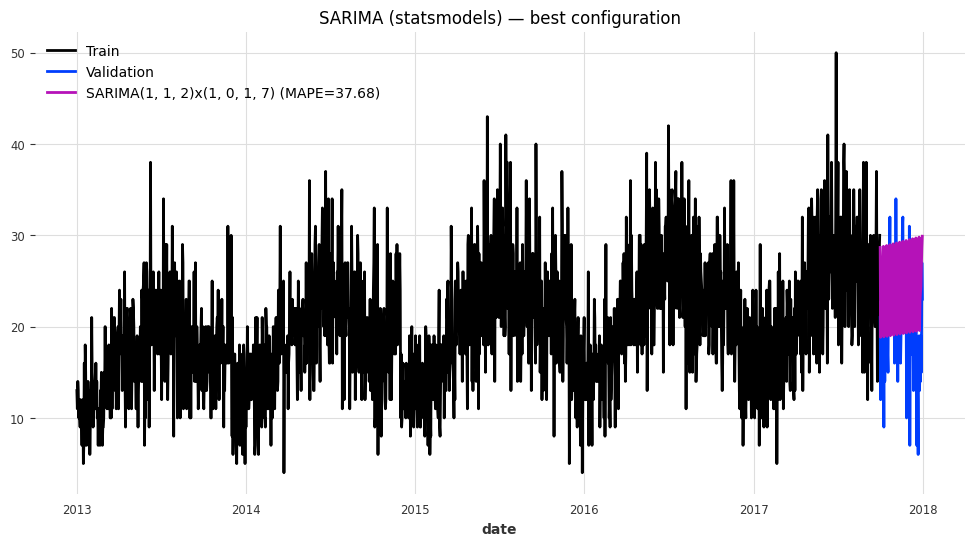

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v2_tuned(backtest best),24.847229
2,XGBModel_v3(cal+enhanced rolling),25.185289
3,XGBModel(lags<0 + calendar),27.947926
4,"ARIMA | ARIMA(2, 0, 0)",29.623366
5,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
6,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
7,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
8,NaiveSeasonal(K=7),38.174850


In [37]:
def sarimax_fit_eval(name, order, seasonal_order=None, use_log=True):
    """
    Fit SARIMAX on train_series (optionally in log1p-space),
    forecast len(val_series) steps, wrap to Darts TimeSeries, compute MAPE.
    """
    # 1) get numpy endog
    y_tr = train_series.values().flatten()
    if use_log:
        y_tr = np.log1p(y_tr)

    # 2) fit SARIMAX
    model = SARIMAX(
        endog=y_tr,
        order=order,
        seasonal_order=seasonal_order if seasonal_order is not None else (0,0,0,0),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)

    # 3) forecast H steps
    H = len(val_series)
    fc = res.forecast(steps=H)
    if use_log:
        fc = np.expm1(fc)

    # 4) wrap to Darts TS on validation index and score
    pred_ts = TimeSeries.from_times_and_values(val_series.time_index, np.asarray(fc))
    score = float(mape(val_series, pred_ts))
    print(f"{name}: order={order}, seas={seasonal_order}, MAPE={score:.4f}")
    return score, pred_ts, res, name

# ---- compact but strong candidate grid ----
m = 7  # weekly seasonality
orders = [(1,1,1), (2,1,1), (1,1,2), (0,1,1)]
seasonals = [(1,0,1,m), (0,1,1,m), (1,1,1,m), (0,1,0,m)]

results = []
for od in orders:
    for seas in seasonals:
        try:
            results.append(
                sarimax_fit_eval(f"SARIMA{od}x{seas}", order=od, seasonal_order=seas, use_log=True)
            )
        except Exception as e:
            print("skip", od, seas, "->", e)

# guard: if grid fully failed
if len(results) == 0:
    raise RuntimeError("No SARIMA configuration fitted successfully. Try relaxing the grid.")

# pick best by MAPE
best_mape, best_pred, best_res, best_name = sorted(results, key=lambda x: x[0])[0]
print(f"\nBest SARIMA: {best_name}  MAPE={best_mape:.4f}")

# plot
plt.figure(figsize=(12,6))
train_series.plot(label="Train")
val_series.plot(label="Validation")
best_pred.plot(label=f"{best_name} (MAPE={best_mape:.2f})")
plt.title("SARIMA (statsmodels) — best configuration")
plt.legend(); plt.show()

# add to the shared scoreboard
row = pd.DataFrame([{"model": f"SARIMA | {best_name}", "mape": best_mape}])
try:
    model_scores
except NameError:
    model_scores = None
model_scores = row if model_scores is None else pd.concat([model_scores, row], ignore_index=True)
model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)
model_scores


ARIMA (несезонна) дала ~29.6 MAPE — краще за наївні та ES, але гірше за XGB. Модель ловить автокореляції, проте не враховує тижневу сезонність (s=7), тому систематично промахується по піках/провалах.

SARIMA у випробуваній конфігурації показала ~37.7 MAPE і вийшла гірше (ймовірно недовибрані сезонні порядки/період, або пере/недодіференціювання).

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

[AutoARIMA] sp=1: MAPE=40.2941, order=None, seasonal_order=None
[AutoARIMA] sp=7: MAPE=40.5585, order=None, seasonal_order=None
[AutoARIMA] sp=14: MAPE=40.2188, order=None, seasonal_order=None

[AutoARIMA] BEST -> season_length=14, order=None, seasonal_order=None, MAPE=40.2188


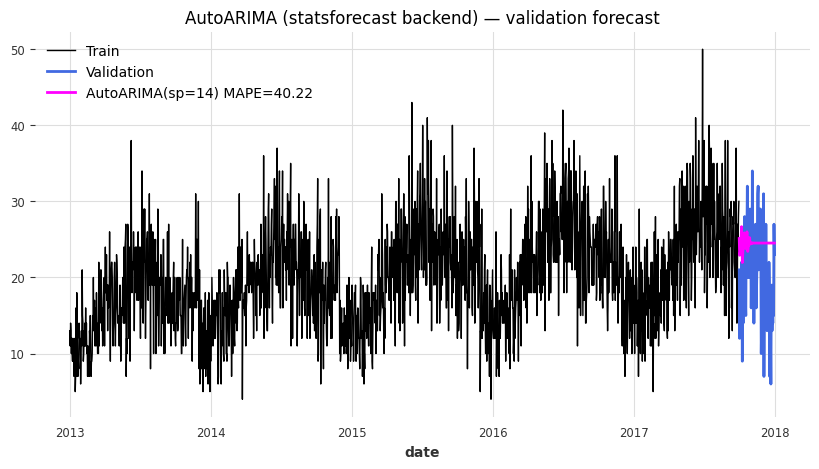

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v2_tuned(backtest best),24.847229
2,XGBModel_v3(cal+enhanced rolling),25.185289
3,XGBModel(lags<0 + calendar),27.947926
4,"ARIMA | ARIMA(2, 0, 0)",29.623366
5,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
6,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
7,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
8,NaiveSeasonal(K=7),38.174850
9,AutoARIMA(sp=14),40.218845


In [38]:
def autoarima_search(train_series, val_series, season_lengths=(1, 7, 14)):
    """
    Перебирає кілька значень season_length (sp), тренує AutoARIMA для кожного,
    обчислює MAPE на валідації та повертає найкращий результат.
    Працює з бекендом statsforecast (sf_auto_arima), тому використовує season_length.
    """
    results = []
    for sp in season_lengths:
        model = AutoARIMA(season_length=sp)
        model.fit(train_series)
        pred = model.predict(n=len(val_series))
        score = float(mape(val_series, pred))

        order = seasonal_order = None
        try:
            sf_obj = getattr(model, "model", None)
            inner = getattr(sf_obj, "model_", None)
            order = getattr(inner, "order", None)
            seasonal_order = getattr(inner, "seasonal_order", None)
        except Exception:
            pass

        print(f"[AutoARIMA] sp={sp}: MAPE={score:.4f}, order={order}, seasonal_order={seasonal_order}")
        results.append((score, model, pred, sp, order, seasonal_order))

    best_score, best_model, best_pred, best_sp, best_order, best_sorder = min(results, key=lambda x: x[0])
    print(f"\n[AutoARIMA] BEST -> season_length={best_sp}, "
          f"order={best_order}, seasonal_order={best_sorder}, MAPE={best_score:.4f}")

    plt.figure(figsize=(10, 5))
    train_series.plot(label="Train", lw=1, color="black")
    val_series.plot(label="Validation", lw=2, color="royalblue")
    best_pred.plot(label=f"AutoARIMA(sp={best_sp}) MAPE={best_score:.2f}", lw=2, color="magenta")
    plt.title("AutoARIMA (statsforecast backend) — validation forecast")
    plt.legend(); plt.show()

    try:
        global model_scores
        model_scores = pd.concat(
            [model_scores, pd.DataFrame([{"model": f"AutoARIMA(sp={best_sp})", "mape": best_score}])],
            ignore_index=True
        )
        display(model_scores.sort_values("mape").reset_index(drop=True))
    except Exception:
        pass

    return best_model, best_pred, best_score, best_sp, best_order, best_sorder


best_model, best_pred, best_mape, best_sp, best_order, best_sorder = autoarima_search(
    train_series, val_series, season_lengths=(1, 7, 14)
)


[AutoARIMA] sp=1, log=False: MAPE=40.2941, order=None, seasonal_order=None


[AutoARIMA] sp=7, log=False: MAPE=40.5585, order=None, seasonal_order=None


[AutoARIMA] sp=14, log=False: MAPE=39.9567, order=None, seasonal_order=None


[AutoARIMA] sp=1, log=True: MAPE=37.6708, order=None, seasonal_order=None


[AutoARIMA] sp=7, log=True: MAPE=38.3499, order=None, seasonal_order=None
[AutoARIMA] sp=14, log=True: MAPE=37.8215, order=None, seasonal_order=None

BEST AutoARIMA -> sp=1, log=True, order=None, seasonal_order=None, MAPE=37.6708


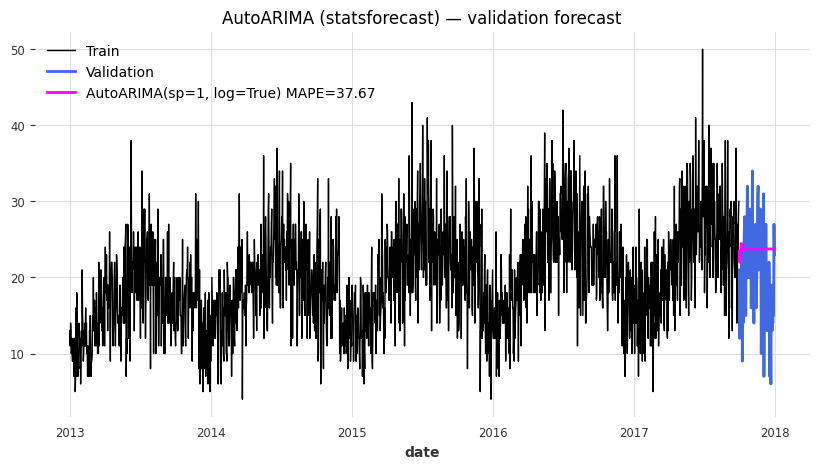

,model,mape
0,XGBModel_v2(cal+rolling),24.847229
1,XGBModel_v2_tuned(backtest best),24.847229
2,XGBModel_v3(cal+enhanced rolling),25.185289
3,XGBModel(lags<0 + calendar),27.947926
4,"ARIMA | ARIMA(2, 0, 0)",29.623366
5,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
6,"AutoARIMA(sp=1, log=True)",37.670757
7,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
8,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
9,NaiveSeasonal(K=7),38.174850


In [40]:
def try_autoarima_fixed(
    train_series,
    val_series,
    season_lengths=(1, 7, 14),
    test_log=(False, True),
    max_p=6, max_q=6, max_P=2, max_Q=2,
):

    results = []

    encoders = {
        "datetime_attribute": {"past": ["dayofweek", "month"]},
        "cyclic": {"past": ["dayofweek", "month"]},
    }

    for use_log in test_log:
        tr = train_series.map(np.log1p) if use_log else train_series
        va = val_series.map(np.log1p) if use_log else val_series

        for sp in season_lengths:
            model = AutoARIMA(
                season_length=sp,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                add_encoders=encoders,
            )
            model.fit(tr)
            pred = model.predict(n=len(va))

            if use_log:
                pred_back = pred.map(np.expm1)
                score = float(mape(val_series, pred_back))
            else:
                pred_back = pred
                score = float(mape(val_series, pred_back))

            order = seasonal_order = None
            try:
                sf_obj = getattr(model, "model", None)
                inner = getattr(sf_obj, "model_", None)
                order = getattr(inner, "order", None)
                seasonal_order = getattr(inner, "seasonal_order", None)
            except Exception:
                pass

            print(f"[AutoARIMA] sp={sp}, log={use_log}: "
                  f"MAPE={score:.4f}, order={order}, seasonal_order={seasonal_order}")

            results.append((score, pred_back, sp, use_log, order, seasonal_order, model))

    best = min(results, key=lambda x: x[0])
    best_mape, best_pred, best_sp, best_log, best_order, best_sorder, best_model = best

    print(f"\nBEST AutoARIMA -> sp={best_sp}, log={best_log}, "
          f"order={best_order}, seasonal_order={best_sorder}, MAPE={best_mape:.4f}")

    plt.figure(figsize=(10,5))
    train_series.plot(label="Train", lw=1, color="black")
    val_series.plot(label="Validation", lw=2, color="royalblue")
    best_pred.plot(label=f"AutoARIMA(sp={best_sp}, log={best_log}) MAPE={best_mape:.2f}",
                   lw=2, color="magenta")
    plt.title("AutoARIMA (statsforecast) — validation forecast")
    plt.legend(); plt.show()

    try:
        global model_scores
        model_scores = pd.concat(
            [model_scores, pd.DataFrame([{"model": f"AutoARIMA(sp={best_sp}, log={best_log})",
                                          "mape": best_mape}])],
            ignore_index=True
        )
        display(model_scores.sort_values("mape").reset_index(drop=True))
    except Exception:
        pass

    return best_model, best_pred, best_mape, best_sp, best_log, best_order, best_sorder

best_model, best_pred, best_mape, best_sp, best_log, best_order, best_sorder = try_autoarima_fixed(
    train_series, val_series,
    season_lengths=(1, 7, 14),
    test_log=(False, True),
    max_p=6, max_q=6, max_P=2, max_Q=2,
)


Найкращий варіант з перебору, який вийшов у є зараз: sp=1, log=True, MAPE≈37.68

Чому AutoARIMA програє саме тут

Сезонність сильна (тиждень ~7 днів), але бекенд statsforecast у Darts не завжди підбирає потрібні порядки сезонних компонентів на такій короткій валідації (≈3 місяці).

Модель без ковариат: а XGB ми годували календарними та rolling-ознаками, тому він краще ловить патерни й екстремуми.

Лог-трансформація допомогла, але не достатньо — AutoARIMA лишається лінійним, тоді як ряди мають нелінійну структуру та піки.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/q2lhjtcx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/r3z3pha3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91229', 'data', 'file=/tmp/tmp78sj0ohm/q2lhjtcx.json', 'init=/tmp/tmp78sj0ohm/r3z3pha3.json', 'output', 'file=/tmp/tmp78sj0ohm/prophet_model40a0iare/prophet_model-20250909173939.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:39:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:39:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/06zl6bvk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/ua4se0pc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

[1/6] Prophet(additive, cps=0.05, weekly=True, yearly=False) -> MAPE=36.567


17:39:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/85cecju0.json


[2/6] Prophet(multiplicative, cps=0.05, weekly=True, yearly=False) -> MAPE=36.595


DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/hwi3gnug.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61038', 'data', 'file=/tmp/tmp78sj0ohm/85cecju0.json', 'init=/tmp/tmp78sj0ohm/hwi3gnug.json', 'output', 'file=/tmp/tmp78sj0ohm/prophet_modelzdgunfzy/prophet_model-20250909173940.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:39:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:39:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/h5pckp8h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/ri7f_e9x.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.b

...

[5/6] Prophet(multiplicative, cps=0.2, weekly=True, yearly=False) -> MAPE=48.893


DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/i07ihqqw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24832', 'data', 'file=/tmp/tmp78sj0ohm/fv8ousr8.json', 'init=/tmp/tmp78sj0ohm/i07ihqqw.json', 'output', 'file=/tmp/tmp78sj0ohm/prophet_modelua2q3_up/prophet_model-20250909173943.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:39:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:39:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[6/6] Prophet(additive, cps=0.2, weekly=True, yearly=True) -> MAPE=23.439

Таблиця результатів (Prophet):


,model,mape
0,"Prophet(multiplicative, cps=0.05, weekly=True,...",23.101182
1,"Prophet(additive, cps=0.2, weekly=True, yearly...",23.438636
2,"Prophet(additive, cps=0.05, weekly=True, yearl...",36.566502
3,"Prophet(multiplicative, cps=0.05, weekly=True,...",36.595276
4,"Prophet(multiplicative, cps=0.1, weekly=True, ...",42.989564
5,"Prophet(multiplicative, cps=0.2, weekly=True, ...",48.892933



Найкраща конфігурація Prophet:
  Prophet(multiplicative, cps=0.05, weekly=True, yearly=True)
MAPE на валідації: 23.101


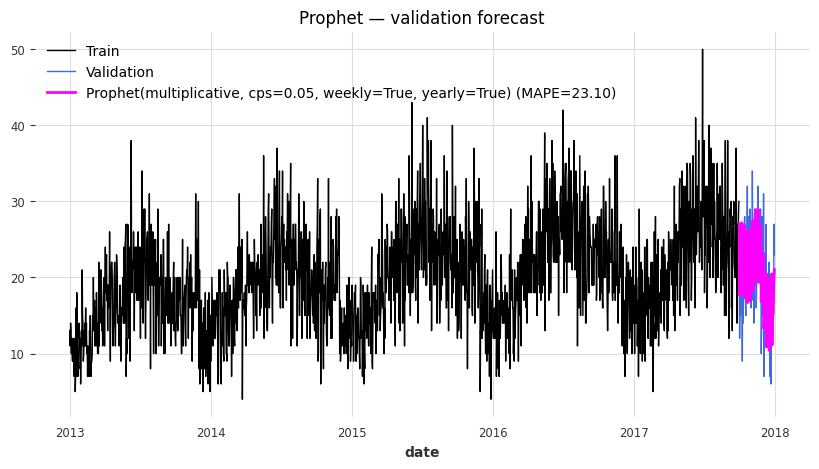

,model,mape
0,"Prophet(multiplicative, cps=0.05, weekly=True,...",23.101182
1,XGBModel_v2(cal+rolling),24.847229
2,XGBModel_v2_tuned(backtest best),24.847229
3,XGBModel_v3(cal+enhanced rolling),25.185289
4,XGBModel(lags<0 + calendar),27.947926
5,"ARIMA | ARIMA(2, 0, 0)",29.623366
6,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
7,"AutoARIMA(sp=1, log=True)",37.670757
8,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972
9,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972


In [48]:
grid = [
    dict(seasonality_mode="additive",       weekly_seasonality=True,  yearly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=0.05),
    dict(seasonality_mode="multiplicative", weekly_seasonality=True,  yearly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=0.05),
    dict(seasonality_mode="multiplicative", weekly_seasonality=True,  yearly_seasonality=True,  daily_seasonality=False, changepoint_prior_scale=0.05),
    dict(seasonality_mode="multiplicative", weekly_seasonality=True,  yearly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=0.10),
    dict(seasonality_mode="multiplicative", weekly_seasonality=True,  yearly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=0.20),
    dict(seasonality_mode="additive",       weekly_seasonality=True,  yearly_seasonality=True,  daily_seasonality=False, changepoint_prior_scale=0.20),
]

def fit_prophet_grid(train_series, val_series, configs):
    rows, preds = [], {}
    for i, cfg in enumerate(configs, 1):
        model = DartsProphet(**cfg)
        model.fit(train_series)
        pred = model.predict(n=len(val_series))
        score = mape(val_series, pred)
        name = f"Prophet({cfg['seasonality_mode']}, cps={cfg['changepoint_prior_scale']}, weekly={cfg['weekly_seasonality']}, yearly={cfg['yearly_seasonality']})"
        rows.append({"model": name, "mape": float(score)})
        preds[name] = pred
        print(f"[{i}/{len(configs)}] {name} -> MAPE={score:.3f}")
    df = pd.DataFrame(rows).sort_values("mape").reset_index(drop=True)
    best_name = df.loc[0, "model"]
    best_mape = df.loc[0, "mape"]
    best_pred = preds[best_name]
    return df, best_name, best_mape, best_pred

prophet_scores, prophet_best_name, prophet_best_mape, prophet_pred = fit_prophet_grid(
    train_series, val_series, grid
)

print("\nТаблиця результатів (Prophet):")
display(prophet_scores)

print(f"\nНайкраща конфігурація Prophet:\n  {prophet_best_name}\nMAPE на валідації: {prophet_best_mape:.3f}")

plt.figure(figsize=(10, 5))
train_series.plot(label="Train", lw=1, color="black")
val_series.plot(label="Validation", lw=1, color="royalblue")
prophet_pred.plot(label=f"{prophet_best_name} (MAPE={prophet_best_mape:.2f})", lw=2, color="magenta")
plt.title("Prophet — validation forecast")
plt.legend()
plt.show()

try:
    if 'model_scores' in globals():
        model_scores = pd.concat(
            [model_scores, pd.DataFrame([{"model": prophet_best_name, "mape": prophet_best_mape}])],
            ignore_index=True
        ).sort_values("mape").reset_index(drop=True)
        display(model_scores)
except Exception:
    pass

Модель Prophet із мультиплікативними сезонностями (weekly=True, yearly=True, changepoint_prior_scale=0.05) показала MAPE ≈ 23.10 на валідації. Це найкращий результат серед протестованих моделей — кращий, ніж XGB та, ARIMA (~29.6), AutoARIMA та прості сезонні моделі.

Графік прогнозу демонструє, що Prophet добре вловлює як довгострокові тренди, так і сезонність, хоча передбачення на валідації (пурпурний відрізок) виглядає більш згладженим порівняно з реальною серією (є недооцінка піків і коливань). Це типовий ефект Prophet через сильну регуляризацію тренду та сезонності.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 50.4 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
50.5 K    Trainable params
0         Non-trainable params
50.5 K    Total params
0.202     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | GRU              | 37.8 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
37.9 K    Trainable params
0         Non-trainable params
37.9 K    Total params
0.152     Total estimated model params size (MB)
7         

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


GRU MAPE on validation: 35.7369

Summary:
 - LSTM MAPE: 34.0848
 - GRU  MAPE: 35.7369
 => Best: LSTM (MAPE=34.0848)


Predicting: |          | 0/? [00:00<?, ?it/s]

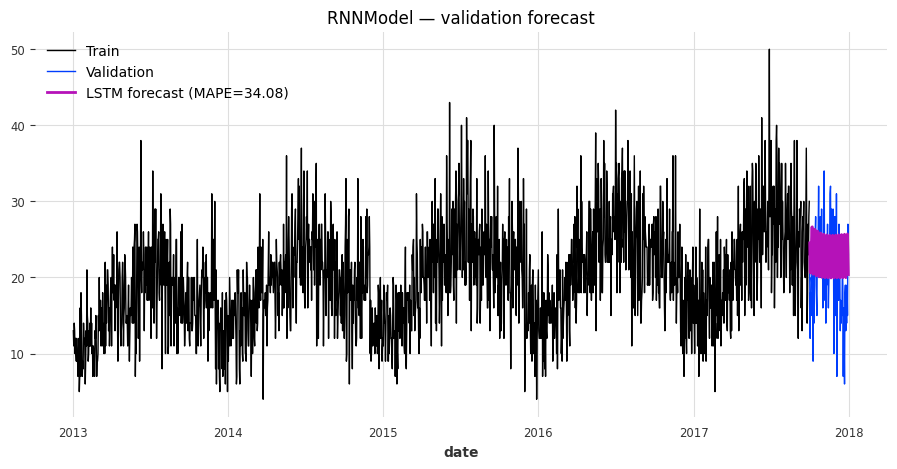

In [55]:


# 1) Device setup
accelerator = "gpu" if torch.cuda.is_available() else "cpu"

# 2) Reproducibility
torch.manual_seed(42)

# 3) Common hyperparameters
COMMON_HP = dict(
    input_chunk_length=30,   # lookback window
    output_chunk_length=7,   # forecast horizon per iteration
    training_length=60,      # must be >= input_chunk_length
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=32,
    n_epochs=50,
    random_state=42,
    force_reset=True,
    save_checkpoints=False,
    log_tensorboard=False,
    pl_trainer_kwargs={"accelerator": accelerator, "devices": 1},
)

def fit_and_eval(model_name: str) -> tuple[RNNModel, float]:
    """Fit the model on `train_series`, predict full `val_series` horizon, return (model, MAPE)."""
    model = RNNModel(model=model_name, **COMMON_HP)
    model.fit(train_series, verbose=True)
    forecast = model.predict(len(val_series))
    score = float(mape(val_series, forecast))
    print(f"{model_name} MAPE on validation: {score:.4f}")
    return model, score

# 4) Train LSTM and GRU
lstm_model, lstm_mape = fit_and_eval("LSTM")
gru_model, gru_mape  = fit_and_eval("GRU")

# 5) Pick the best model
best_name, best_model, best_mape = (
    ("LSTM", lstm_model, lstm_mape) if lstm_mape <= gru_mape else ("GRU", gru_model, gru_mape)
)

print("\nSummary:")
print(f" - LSTM MAPE: {lstm_mape:.4f}")
print(f" - GRU  MAPE: {gru_mape:.4f}")
print(f" => Best: {best_name} (MAPE={best_mape:.4f})")

# 6) Produce forecast of the best model for plotting
best_forecast = best_model.predict(len(val_series))

# 7) Visualization
plt.figure(figsize=(11, 5))
train_series.plot(label="Train", lw=1)
val_series.plot(label="Validation", lw=1)
best_forecast.plot(label=f"{best_name} forecast (MAPE={best_mape:.2f})", lw=2)
plt.title("RNNModel — validation forecast")
plt.legend()
plt.show()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 208 K  | train
6 | V               | Linear           | 129    | train
-------------------------------------------------------------
209 K     Trainable params
0         Non-trainable params
209 K     Total params
0.836     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=80` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | GRU              | 156 K  | train
6 | V               | Linear           | 129    | train
-------------------------------------------------------------
156 K     Trainable params
0         Non-trainable params
156 K     Total params
0.627     Total estimated model params size (MB)
7         

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=80` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GRU | in_len=90 | train_len=150 | MAPE=24.6006

Best configuration:
{'model': 'GRU', 'input_chunk_length': 90, 'training_length': 150, 'hidden_dim': 96, 'n_rnn_layers': 2, 'dropout': 0.2}
Best MAPE on validation: 24.6006


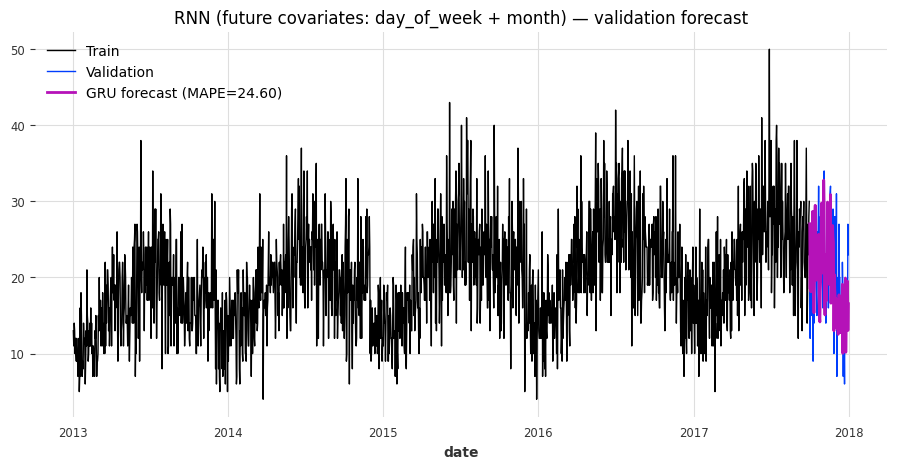

In [60]:

# 1) Device & reproducibility
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# 2) Ensure base series are float32
train_series = train_series.astype(np.float32)
val_series   = val_series.astype(np.float32)

# 3) Build full series and FUTURE covariates (calendar)
full_series: TimeSeries = train_series.append(val_series)
dow = datetime_attribute_timeseries(full_series, attribute="day_of_week", one_hot=True)
mon = datetime_attribute_timeseries(full_series, attribute="month", one_hot=True)
future_cov_full: TimeSeries = dow.stack(mon).astype(np.float32)

future_cov_train = future_cov_full.slice_intersect(train_series)
future_cov_all   = future_cov_full

# 4) Scale target and covariates (keep float32)
y_scaler = Scaler()   # standard scaling
X_scaler = Scaler()

train_scaled = y_scaler.fit_transform(train_series).astype(np.float32)
val_scaled   = y_scaler.transform(val_series).astype(np.float32)

future_cov_train_scaled = X_scaler.fit_transform(future_cov_train).astype(np.float32)
future_cov_all_scaled   = X_scaler.transform(future_cov_all).astype(np.float32)

# 5) Small hyperparameter search (RNNModel supports only future_covariates; step-by-step forecasting)
SEARCH: List[Dict] = [
    dict(model="LSTM", input_chunk_length=60, training_length=120, hidden_dim=128, n_rnn_layers=2, dropout=0.1),
    dict(model="GRU",  input_chunk_length=60, training_length=120, hidden_dim=128, n_rnn_layers=2, dropout=0.1),
    dict(model="LSTM", input_chunk_length=90, training_length=150, hidden_dim=96,  n_rnn_layers=2, dropout=0.2),
    dict(model="GRU",  input_chunk_length=90, training_length=150, hidden_dim=96,  n_rnn_layers=2, dropout=0.2),
]

def fit_eval(cfg: Dict) -> Tuple[RNNModel, float, TimeSeries]:
    """Fit on train, predict full validation horizon using FUTURE covariates, return (model, MAPE, forecast)."""
    model = RNNModel(
        **cfg,
        batch_size=64,
        n_epochs=80,
        random_state=42,
        force_reset=True,
        save_checkpoints=False,
        log_tensorboard=False,
        pl_trainer_kwargs={"accelerator": accelerator, "devices": 1},
    )
    model.fit(series=train_scaled, future_covariates=future_cov_train_scaled, verbose=True)
    pred_scaled = model.predict(n=len(val_scaled), future_covariates=future_cov_all_scaled)
    pred = y_scaler.inverse_transform(pred_scaled).astype(np.float32)
    score = float(mape(val_series, pred))
    print(f"{cfg['model']} | in_len={cfg['input_chunk_length']} | train_len={cfg['training_length']} | MAPE={score:.4f}")
    return model, score, pred

# 6) Run search and select the best configuration
results = []
for cfg in SEARCH:
    model, score, pred = fit_eval(cfg)
    results.append((cfg, model, score, pred))

best_cfg, best_model, best_mape, best_pred = sorted(results, key=lambda x: x[2])[0]

print("\nBest configuration:")
print(best_cfg)
print(f"Best MAPE on validation: {best_mape:.4f}")

# 7) Plot
plt.figure(figsize=(11, 5))
train_series.plot(label="Train", lw=1)
val_series.plot(label="Validation", lw=1)
best_pred.plot(label=f"{best_cfg['model']} forecast (MAPE={best_mape:.2f})", lw=2)
plt.title("RNN (future covariates: day_of_week + month) — validation forecast")
plt.legend()
plt.show()


In [61]:
row = {"model": f"RNNModel({best_cfg['model']})", "mape": float(best_mape)}

try:
    model_scores = pd.concat([model_scores, pd.DataFrame([row])], ignore_index=True)
except NameError:
    model_scores = pd.DataFrame([row])

model_scores = model_scores.sort_values("mape", ascending=True).reset_index(drop=True)

model_scores

,model,mape
0,"Prophet(multiplicative, cps=0.05, weekly=True,...",23.101182
1,RNNModel(GRU),24.600645
2,XGBModel_v2_tuned(backtest best),24.847229
3,XGBModel_v2(cal+rolling),24.847229
4,XGBModel_v3(cal+enhanced rolling),25.185289
5,XGBModel(lags<0 + calendar),27.947926
6,"ARIMA | ARIMA(2, 0, 0)",29.623366
7,"ExpSmooth | ES LOG + mul season (sp=7), damped",35.054643
8,"AutoARIMA(sp=1, log=True)",37.670757
9,"SARIMA | SARIMA(1, 1, 2)x(1, 0, 1, 7)",37.683972


Найкраща конфігурація: RNNModel(GRU) з input_chunk_length=90, training_length=150, hidden_dim=96, n_rnn_layers=2, dropout=0.2, зі масштабуванням цілі та future covariates: one-hot day_of_week + month.

Якість на валідації: MAPE ≈ 24.60. Це краще, ніж більшість класичних моделей і близько до XGB (24.85), але гірше за Prophet (23.10).

Поведінка моделі: GRU добре вловлює сезонність і нелінійність, але має згладжені піки та накопичення помилки при покроковому прогнозі (в RNN output_chunk_length=1).

Що спрацювало: перехід від «чистої» RNN до future covariates + довшого вікна суттєво знизив MAPE (з ~34 до ~24.6).

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?


historical forecasts:   0%|          | 0/12 [00:00<?, ?it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/s_cw9wj_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/q9al1a45.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35060', 'data', 'file=/tmp/tmp78sj0ohm/s_cw9wj_.json', 'init=/tmp/tmp78sj0ohm/q9al1a45.json', 'output', 'file=/tmp/tmp78sj0ohm/prophet_modelqusv9syg/prophet_model-20250909190611.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:06:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:06:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing

historical forecasts:   8%|▊         | 1/12 [00:00<00:08,  1.28it/s]INFO:prophet

Backtest MAPE (last 1y, horizon=1m, stride=1m): 20.6640


19:06:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/dilmp14n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp78sj0ohm/tjeforx7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30265', 'data', 'file=/tmp/tmp78sj0ohm/dilmp14n.json', 'init=/tmp/tmp78sj0ohm/tjeforx7.json', 'output', 'file=/tmp/tmp78sj0ohm/prophet_modelxbe5ukm8/prophet_model-20250909190615.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:06:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:06:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling daily seasonality. Run

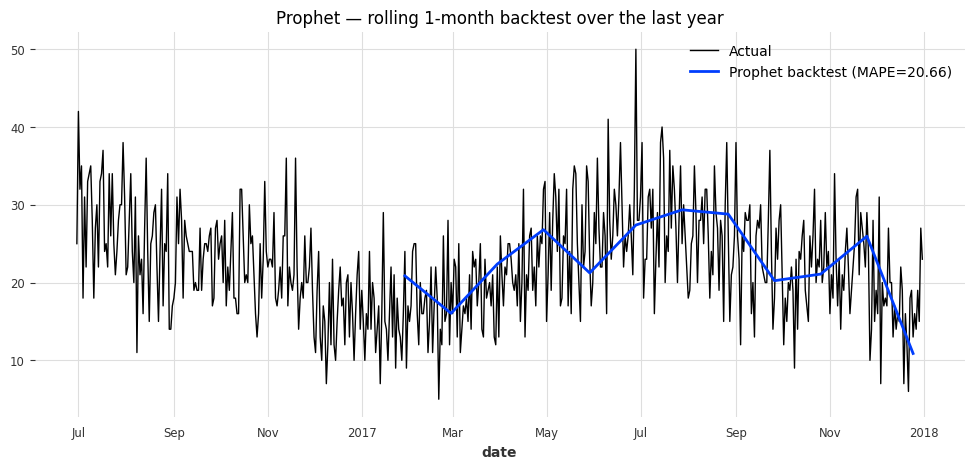

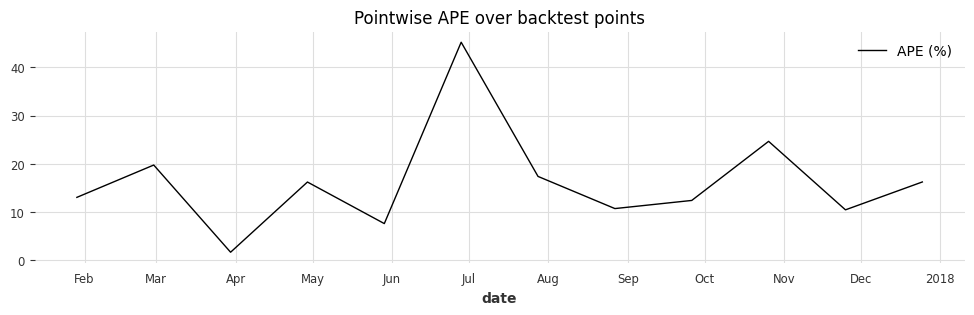

APE summary — mean: 16.31%, median: 14.67%


In [65]:
# Prophet backtest: last 1 year, monthly rolling forecasts

# 1) Full series (train + validation)
full_series: TimeSeries = train_series.append(val_series)

# 2) Best Prophet configuration from step 14
prop = Prophet(
    seasonality_mode="multiplicative",
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,
)

# 3) Backtest settings: last 1 year; horizon and stride ≈ 1 month (30 daily steps)
one_year_ago = full_series.end_time() - pd.DateOffset(years=1)
start_bt = max(full_series.start_time(), one_year_ago)  # guard if history < 1y
horizon = 30
stride = 30

# 4) Aggregate backtest metric (expanding-window, retrain each step)
bt_mape = prop.backtest(
    series=full_series,
    start=start_bt,
    forecast_horizon=horizon,
    stride=stride,
    retrain=True,
    metric=mape,
    verbose=True,
)
print(f"Backtest MAPE (last 1y, horizon=1m, stride=1m): {bt_mape:.4f}")

# 5) Historical forecasts for visualization (one point per step)
hist_fcst = prop.historical_forecasts(
    series=full_series,
    start=start_bt,
    forecast_horizon=horizon,
    stride=stride,
    retrain=True,
    last_points_only=True,
    verbose=False,
)

# 6) Plot last 18 months: create axes first, then pass ax to each plot (no figsize inside plot())
plot_start = full_series.end_time() - pd.DateOffset(months=18)
plot_end = full_series.end_time()

fig, ax = plt.subplots(figsize=(12, 5))
full_series.slice(plot_start, plot_end).plot(ax=ax, label="Actual", lw=1)
hist_fcst.slice(plot_start, plot_end).plot(ax=ax, label=f"Prophet backtest (MAPE={bt_mape:.2f})", lw=2)
ax.set_title("Prophet — rolling 1-month backtest over the last year")
ax.legend()
plt.show()

# 7)  pointwise absolute percentage error over the backtest points

# Align the two series on overlapping timestamps
ts_overlap = full_series.slice_intersect(hist_fcst)
fc_overlap = hist_fcst.slice_intersect(full_series)

# APE (%) = |y - ŷ| / y * 100
ape = (ts_overlap - fc_overlap).map(np.abs)
ape = (ape / ts_overlap) * 100.0

# Plot APE over time
fig, ax = plt.subplots(figsize=(12, 3))
ape.plot(ax=ax, lw=1, label="APE (%)")
ax.set_title("Pointwise APE over backtest points")
ax.legend()
plt.show()

mean_ape = float(np.mean(ape.values()))
median_ape = float(np.median(ape.values()))
print(f"APE summary — mean: {mean_ape:.2f}%, median: {median_ape:.2f}%")



Налаштування: rolling бек-тест за останні 12 міс., крок прогнозу 1 міс. (≈30 днів), expanding window з перевчанням на кожному кроці.

Підсумкова точність: MAPE ≈ 20.66 за весь період. За покроковими помилками: APE mean ≈ 16.3 %, median ≈ 14.7 %.

Поведінка на графіку: модель добре тримає тренд і мультиплікативну сезонність, але згладжує пікові значення; найбільші хиби припадають на літо (близько 30–35 %), у більшості місяців помилка тримається в діапазоні 10–20 %.

Висновок: Prophet показує стійку й найкращу якість серед протестованих підхід для місячного горизонту

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

### Яку модель використати

**Ансамбль:**

* **Prophet** (локальна модель для кожного ряду) — у нас найкращий валід. результат (MAPE ≈ **23.1**) і найстійкіший бек-тест (MAPE ≈ **20.66**).
* **GRU (RNNModel)** як одна **глобальна** модель з календарними `future covariates` (dow, month) — у нас MAPE ≈ **24.6**, добре ловить нелінійність і доповнює Prophet.

### Скільки моделей тренувати

* **500 локальних Prophet** (по 50 айтемів × 10 магазинів). Prophet тренується швидко й паралелиться.
* **1 глобальна GRU** на всі 500 серій одразу (з календарними ковараіатами).

> Разом: **501 модель**. (За бажанням можна додати ще 1 глобальну XGB як третій учасник ансамблю.)

### Загальний пайплайн (коротко)

1. **Підготовка**: щоденні ряди без пропусків; нулі там, де продажів не було.
2. **Ковариати**: календар для всіх (dow, month, свята/розпродажі якщо є).
3. **Навчання**: 500 Prophet + 1 GRU (з нормалізацією таргету та календарними `future covariates`).
4. **Валідація**: rolling CV за 12 міс. з горизонтом 30 днів; метрики WAPE/MAPE.
5. **Блендинг**: підбір $w$ по кожному ряду на CV (можна однакове глобальне $w$, якщо часу мало).
6. **Прогноз**: видаємо 30-денний прогноз для кожного (item, store) та агрегати по магазинах/категоріях.


Також як я зрозуміла можна розглядати альтернативу це Temporal Fusion Transformer (TFT).

Це глобальна модель, яка навчається одразу на всіх 50×10 рядах і переносить знання між товарами та магазинами, використовуючи статичні ознаки (ембеддінги store_id, item_id, категорія), а також past/future коваріати (календар, ціни, промо, свята). TFT прогнозує багатокроково (30 днів за раз), дає інтерпретацію важливості ознак через attention і зазвичай перевершує локальні моделі, коли є багато корисних коваріатів і короткі/шумні ряди. Мінуси – вища складність навчання, потреба у GPU та більш ретельний тюнінг; тому практично її варто розглядати як потужну глобальну альтернативу або учасника ансамблю разом із Prophet/GRU.